# Imports

In [1]:
# Automatically reloads modules before each cell execution, so code changes in library are always propogated.
#reload or load? _ext
%load_ext autoreload
%autoreload 2

%load_ext snakeviz

import networkx as nx
from networkx import MultiDiGraph
import osmnx as ox
import numpy as np
import pandas as pd
from difflib import SequenceMatcher
import concurrent.futures
import copy
import re
from tqdm.notebook import tqdm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

from typing import Literal

from NetworkOptimisation import graph_optimisation_heuristic
from PreProcessing import graph_preprocessing, enrich_attributes, graph_structure
from NetworkOptimisation import heuristic, mathematical
from Demand import ODGeneration, paths_util
import Plotting

import graph_util as graph_util
import investigation
import constants

from constants import OD

ox.settings.useful_tags_way = [
    "bridge", "tunnel", "oneway", "lanes", "highway",
     "width", "name", "name:en", "bicycle", "cycleway", "tunnel"]

LOCATION = "Gozo, Malta"
#LOCATION = "Malta (island)"
safe_location = re.sub(r"[()\[\]{}]", "", LOCATION)
safe_location = re.sub(r"[^0-9A-Za-z_-]+", "_", safe_location)
safe_location = re.sub(r"_+", "_", safe_location).strip("_")

GRAPH_PATH = f"../Data/{safe_location}_master_graph.graphml"
SEED = 72
K_SAMPLE = 100 #NOTE TODO 100 preserves rank but for accurate values use 400; k=50 is the lowest acceptable 
N_ITERATIONS = 20 

rng = np.random.default_rng(SEED)

# Generate and save master graph

Loading OSM networks for Gozo, Malta...
creating master graph network...


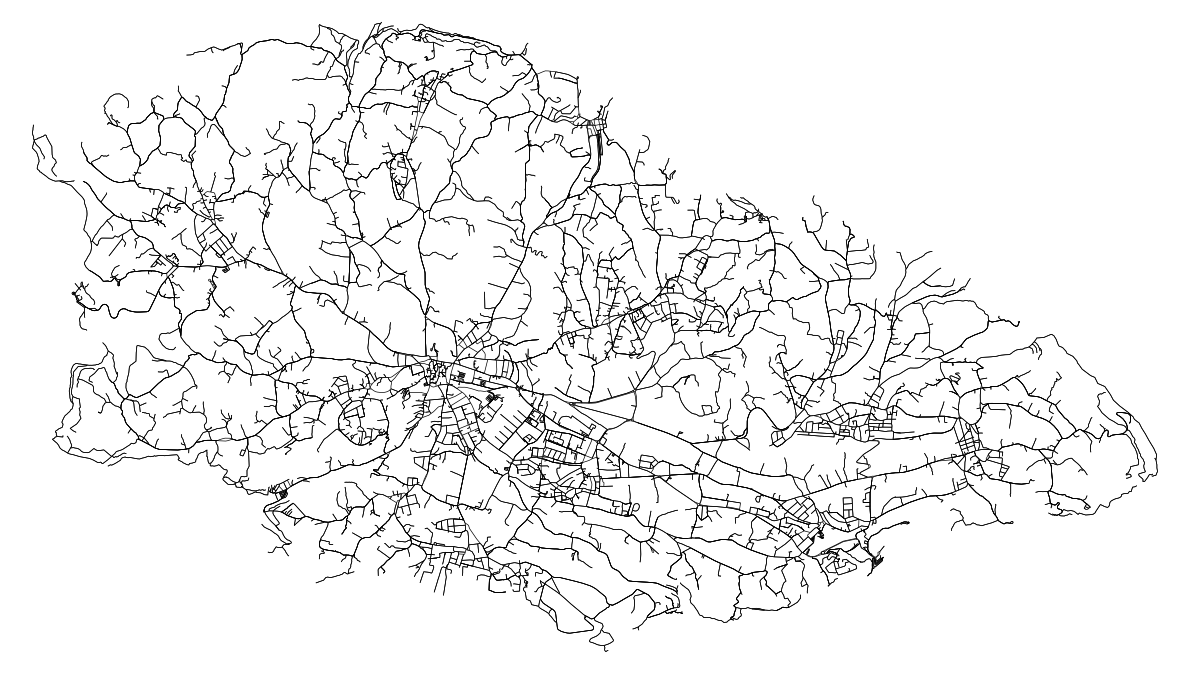

Adding elevation data.....
Imputing missing elevation values
Iteration 1: imputed 29 nodes
Iteration 2: imputed 5 nodes
Iteration 3: imputed 2 nodes
Iteration 4: imputed 0 nodes


c:\Users\Pirot\Documents\GitHub\FYP-OpenPaths\.venv\Lib\site-packages\osmnx\routing.py:577: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  edges[["highway", "speed_kph"]].set_index("highway").iloc[:, 0].fillna(hwy_speed_avg)


 30.0 kph : 7270
 50.0 kph : 1287
 60.0 kph : 3855
Reallocatability summary: [('total', 13058), ('no_car_allowed', 8089), ('reallocatable', 4969)]
Number of localities: 15


In [2]:
#NOTE the length attribute is given in meters
#You project not to fix lengths, but to make sure your geometry math (like areas or spatial intersections) makes sense in linear units.
#Simplify is used to significantly reduce the number of nodes, removing dead ends and combining nodes with no intersections
G_master = graph_preprocessing.load_network(LOCATION)

fig, ax = Plotting.draw_graph(G_master)
ax.axis("off")
fig.tight_layout()
plt.show()

G_master, gdf_regions_proj, gdf_local_proj = graph_preprocessing.clean_graph(G_master, LOCATION)

197798 1497329566 0


{'seg': (197798, 1497329566, 0),
 'arcs': [(197798, 1497329566, 0), (1497329566, 197798, 0)],
 'n_arcs': 2,
 'length': np.float64(8402692.93419991),
 'grade': 0.0,
 'risk_factor': 4.0,
 'speed_kph_original': 60.0,
 'speed_kph_current': 60.0,
 'car_lanes': 1,
 'bike_lanes': 1,
 'car_allowed': True,
 'bike_allowed': False,
 'highway': 'primary',
 'safety': <SafetyClass.DANGEROUS: 'dangerous'>,
 'geometry': <LINESTRING (435890.692 3986839.052, 435904.483 3986833.56, 435927.949 39868...>,
 'bike_cost_base': 1850040.841411364,
 'bike_cost_penalty': 7400163.365645456}

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

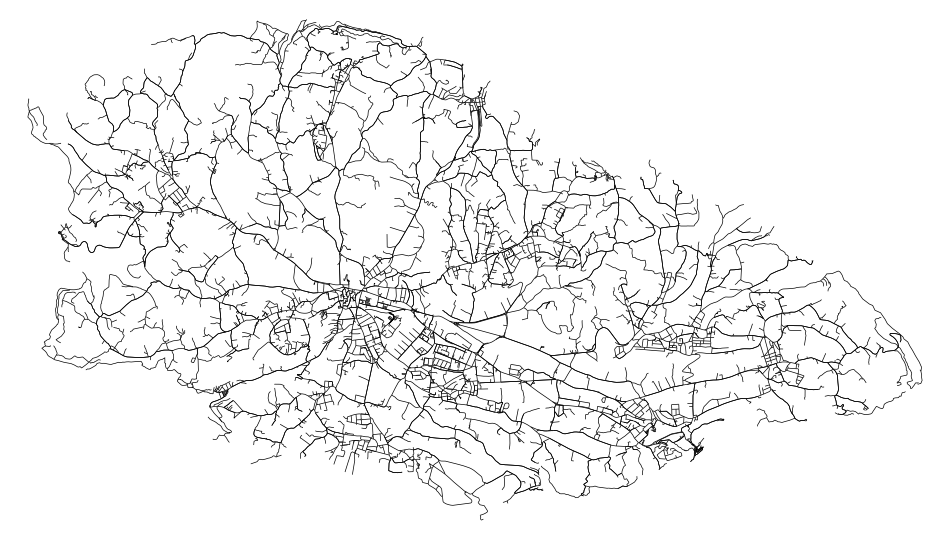

In [3]:
_, _,  G_undirected = graph_structure.build_segment_graph(G_master)

edges = list(G_undirected.edges(keys=True, data=True))
u, v, k, data = edges[0]
print(u, v, k)
display(data)

Plotting.renderer.draw_graph(G_undirected)


(<Figure size 7600x7200 with 2 Axes>,
 <Axes: title={'center': 'Car lanes count'}>)

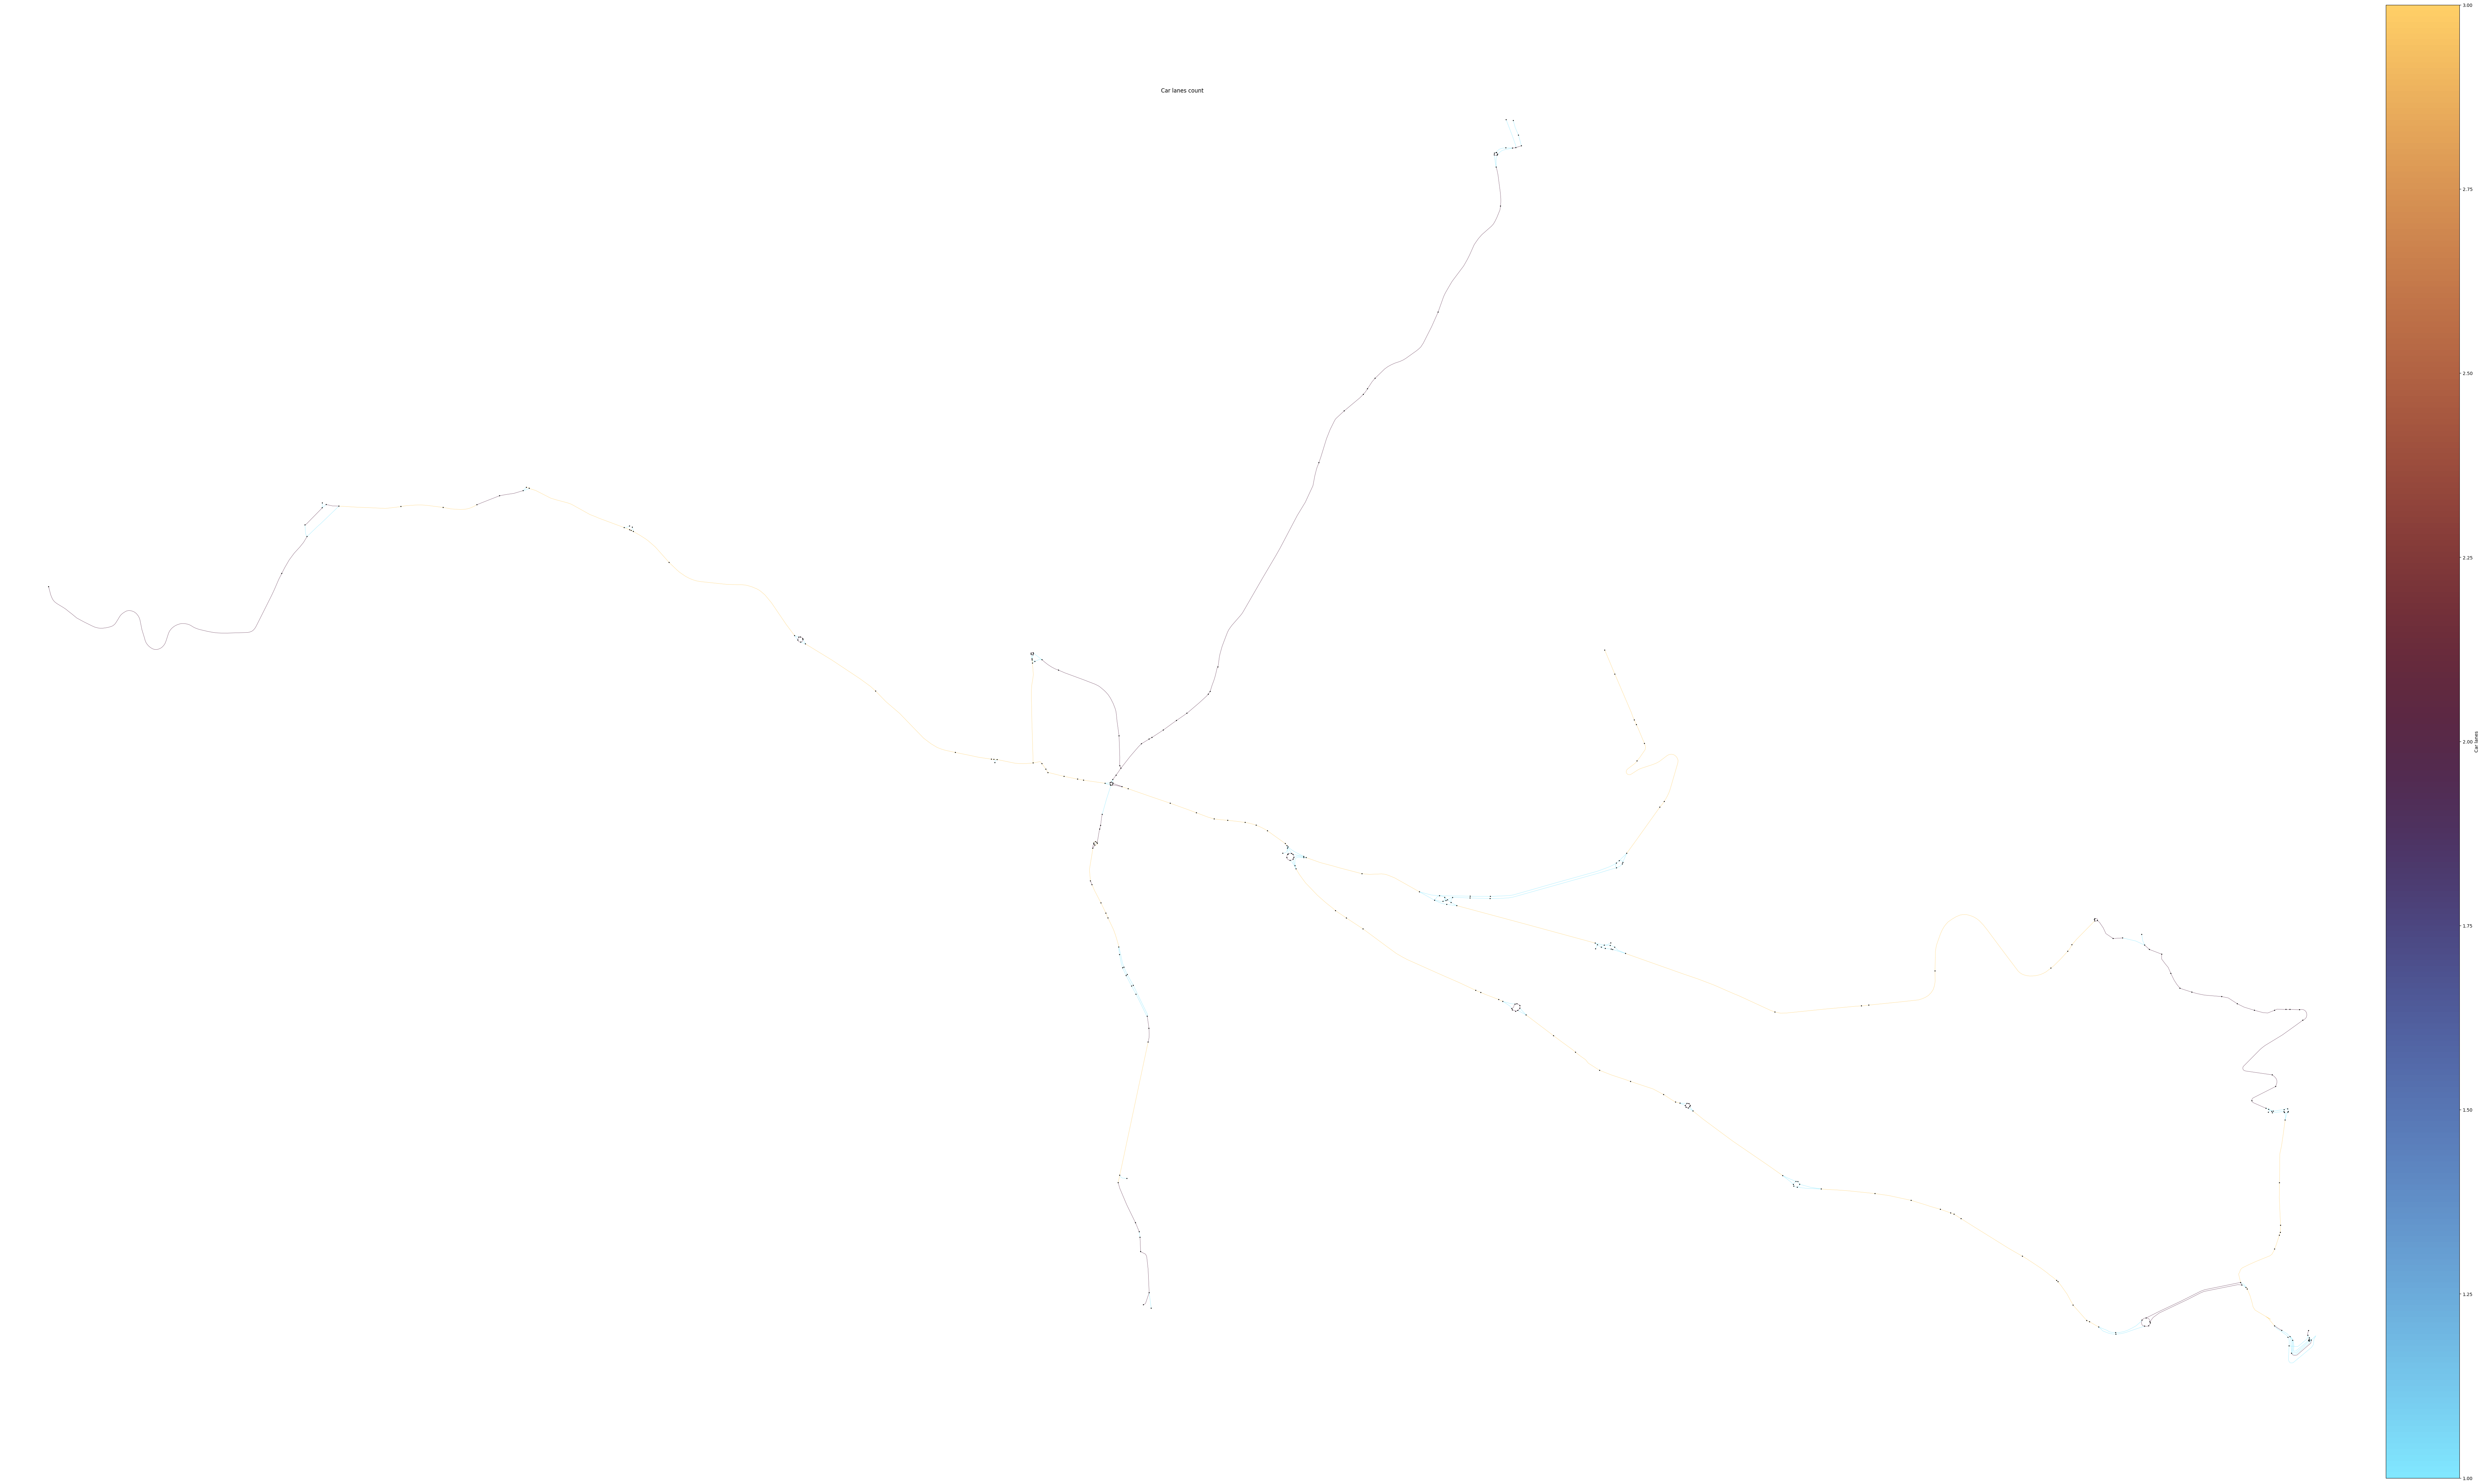

In [4]:
#TODO I have car lanes on edges that are not on G_drive?
import matplotlib.colors as mcolors

_, _, G_undirected = graph_structure.build_segment_graph(G_master)

G_drive = graph_util.make_drive_subgraph(G_master)
_, _,  G_drive_undirected = graph_structure.build_segment_graph(G_drive)

G_drive_undirected_main= graph_util.make_highway_subgraph(G_drive_undirected, "primary")


Plotting.plot_graph_by_edge_attr(
    G_drive_undirected_main, attr="car_lanes", title="Car lanes count", label="Car lanes",
    norm=mcolors.Normalize(vmin=1, vmax=3, clip=True), fig_size=(76,72), node_size=5)

In [5]:
G_drive = graph_util.make_drive_subgraph(G_master)
enrich_attributes.tag_reallocatable_edges(G_drive)

Counter({'reallocatable': 4969, 'total': 4969})

In [6]:
edges = list(G_master.edges(keys=True, data=True))
u, v, k, data = edges[0]
print(u, v, k)
display(data)

197798 1497329566 0


{'osmid': [139266489, 1182920597],
 'oneway': True,
 'highway': 'primary',
 'name': 'Triq l-Imġarr',
 'name:en': 'Mġarr Road',
 'reversed': False,
 'length': np.float64(8402692.93419991),
 'geometry': <LINESTRING (435890.692 3986839.052, 435904.483 3986833.56, 435927.949 39868...>,
 'car_allowed': True,
 'bike_allowed': False,
 'grade': -0.038010328418853705,
 'grade_abs': 0.038010328418853705,
 'speed_kph': 60.0,
 'speed_kph_original': 60.0,
 'speed_kph_current': 60.0,
 'car_lanes': 1,
 'bike_lanes': 1,
 'infra_type': 'car',
 'safety': <SafetyClass.DANGEROUS: 'dangerous'>,
 'risk_factor': 4.0,
 'bike_cost_base': np.float64(1508520.5071319938),
 'bike_cost_penalty': np.float64(6034082.028527975),
 'car_cost_current': np.float64(504161.5760519946),
 'reallocatable': True,
 'regions': ['Reġjun Għawdex'],
 'localities': ['Għajnsielem']}

In [7]:
graph_util.summarise_road_type_stats(G_master)

Highway type counts:
residential: 5753
track: 1859
service: 1789
tertiary: 1396
primary: 1122
secondary: 763
non_motorised: 376
-------
bikeway classification type counts:
None: 12562
yes: 492
permissive: 4
------
cycleway type counts:
None: 13014
no: 44
------
tunnel counts:
None: 13032
yes: 20
building_passage: 6


In [8]:
ox.io.save_graphml(G_master, filepath=GRAPH_PATH)

gdf_local_proj.to_pickle(f"../Data/{safe_location}_gdf_local_proj.pkl")
gdf_regions_proj.to_pickle(f"../Data/{safe_location}_gdf_regions_proj.pkl")

# Load mastergraph

In [9]:
#NOTE removed loading cos its causing too much hassle (esp lists) and doesnt even save that much time
"""G_master = ox.io.load_graphml(
    filepath=GRAPH_PATH,
    edge_dtypes={
        "car_lanes": int,
        "bike_lanes": int,
        "car_allowed": ox.io._convert_bool_string,
        "bike_allowed": ox.io._convert_bool_string,
        "reallocatable": ox.io._convert_bool_string,
        "grade": float,
        "grade_abs": float,
        "risk_factor": float,
        "bike_cost_base": float, # This is just he base cost of distance and grade
        "bike_cost_penalty": float, # This takes into account percieved travel time due to cars
        "speed_kph_original":float. # Original derived max car speed 
        "speed_kph_current": float, # current max kph
        "car_cost_current":float, # The typical travel cost
        "car_cost_if_fietsstraat":float, # The cost if the edge was set to fietsstraat
        "regions": list[str],
        "localities": list[str],
        "highway"?
        "bicycle"?
        "cycleway"?
    },
    node_dtypes={
        "elevation": float
    })

gdf_local_proj = pd.read_pickle(f"../Data/{safe_location}_gdf_local_proj.pkl")
gdf_regions_proj = pd.read_pickle(f"../Data/{safe_location}_gdf_regions_proj.pkl")"""

'G_master = ox.io.load_graphml(\n    filepath=GRAPH_PATH,\n    edge_dtypes={\n        "car_lanes": int,\n        "bike_lanes": int,\n        "car_allowed": ox.io._convert_bool_string,\n        "bike_allowed": ox.io._convert_bool_string,\n        "reallocatable": ox.io._convert_bool_string,\n        "grade": float,\n        "grade_abs": float,\n        "risk_factor": float,\n        "bike_cost_base": float, # This is just he base cost of distance and grade\n        "bike_cost_penalty": float, # This takes into account percieved travel time due to cars\n        "speed_kph_original":float. # Original derived max car speed \n        "speed_kph_current": float, # current max kph\n        "car_cost_current":float, # The typical travel cost\n        "car_cost_if_fietsstraat":float, # The cost if the edge was set to fietsstraat\n        "regions": list[str],\n        "localities": list[str],\n        "highway"?\n        "bicycle"?\n        "cycleway"?\n    },\n    node_dtypes={\n        "eleva

In [10]:
edges = list(G_master.edges(keys=True, data=True))
u, v, k, data = edges[0]
print(u, v, k)
display(data)

197798 1497329566 0


{'osmid': [139266489, 1182920597],
 'oneway': True,
 'highway': 'primary',
 'name': 'Triq l-Imġarr',
 'name:en': 'Mġarr Road',
 'reversed': False,
 'length': np.float64(8402692.93419991),
 'geometry': <LINESTRING (435890.692 3986839.052, 435904.483 3986833.56, 435927.949 39868...>,
 'car_allowed': True,
 'bike_allowed': False,
 'grade': -0.038010328418853705,
 'grade_abs': 0.038010328418853705,
 'speed_kph': 60.0,
 'speed_kph_original': 60.0,
 'speed_kph_current': 60.0,
 'car_lanes': 1,
 'bike_lanes': 1,
 'infra_type': 'car',
 'safety': <SafetyClass.DANGEROUS: 'dangerous'>,
 'risk_factor': 4.0,
 'bike_cost_base': np.float64(1508520.5071319938),
 'bike_cost_penalty': np.float64(6034082.028527975),
 'car_cost_current': np.float64(504161.5760519946),
 'reallocatable': True,
 'regions': ['Reġjun Għawdex'],
 'localities': ['Għajnsielem']}

# Network Inspection

## Road type classification

In [11]:
graph_util.summarise_road_type_stats(G_master)

Highway type counts:
residential: 5753
track: 1859
service: 1789
tertiary: 1396
primary: 1122
secondary: 763
non_motorised: 376
-------
bikeway classification type counts:
None: 12562
yes: 492
permissive: 4
------
cycleway type counts:
None: 13014
no: 44
------
tunnel counts:
None: 13032
yes: 20
building_passage: 6


In [12]:
print("G_Master:")
print("Nodes:", G_master.number_of_nodes())
print("Edges (total, counts parallel edges separately):", G_master.number_of_edges())
print(G_master.graph)

print("-----")
print("G_Drive")
G_drive = graph_util.make_drive_subgraph(G_master)
print("Nodes:", G_drive.number_of_nodes())
print("Edges (total, counts parallel edges separately):", G_drive.number_of_edges())
print(G_drive.graph)

G_Master:
Nodes: 4994
Edges (total, counts parallel edges separately): 13058
{'created_date': '2026-02-26 13:41:24', 'created_with': 'OSMnx 2.0.5', 'crs': <Projected CRS: EPSG:32633>
Name: WGS 84 / UTM zone 33N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°E and 18°E, northern hemisphere between equator and 84°N, onshore and offshore. Austria. Bosnia and Herzegovina. Cameroon. Central African Republic. Chad. Congo. Croatia. Czechia. Democratic Republic of the Congo (Zaire). Gabon. Germany. Hungary. Italy. Libya. Malta. Niger. Nigeria. Norway. Poland. San Marino. Slovakia. Slovenia. Svalbard. Sweden. Vatican City State.
- bounds: (12.0, 0.0, 18.0, 84.0)
Coordinate Operation:
- name: UTM zone 33N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
, 'simplified': True}
-----
G_Drive
Nodes: 2056
Edges (total, counts parallel edges separately): 4969
{'create

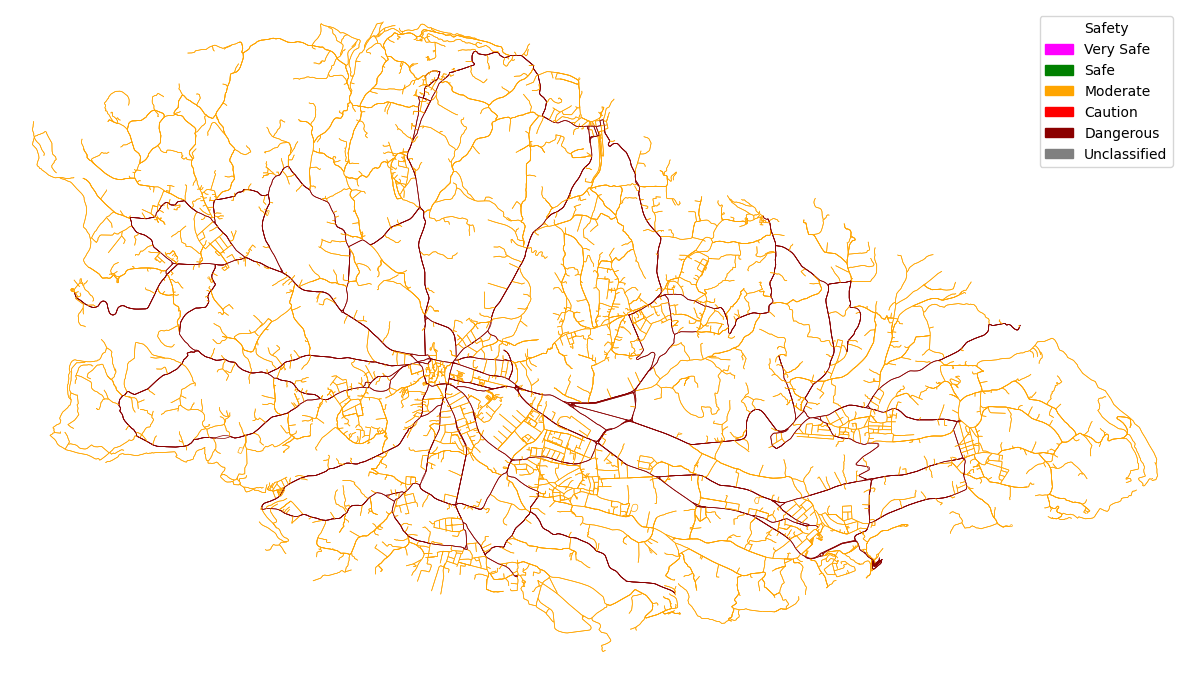

In [13]:
Plotting.plot_categorical_attr(G_master, "safety", constants.SAFETY_COLORS)

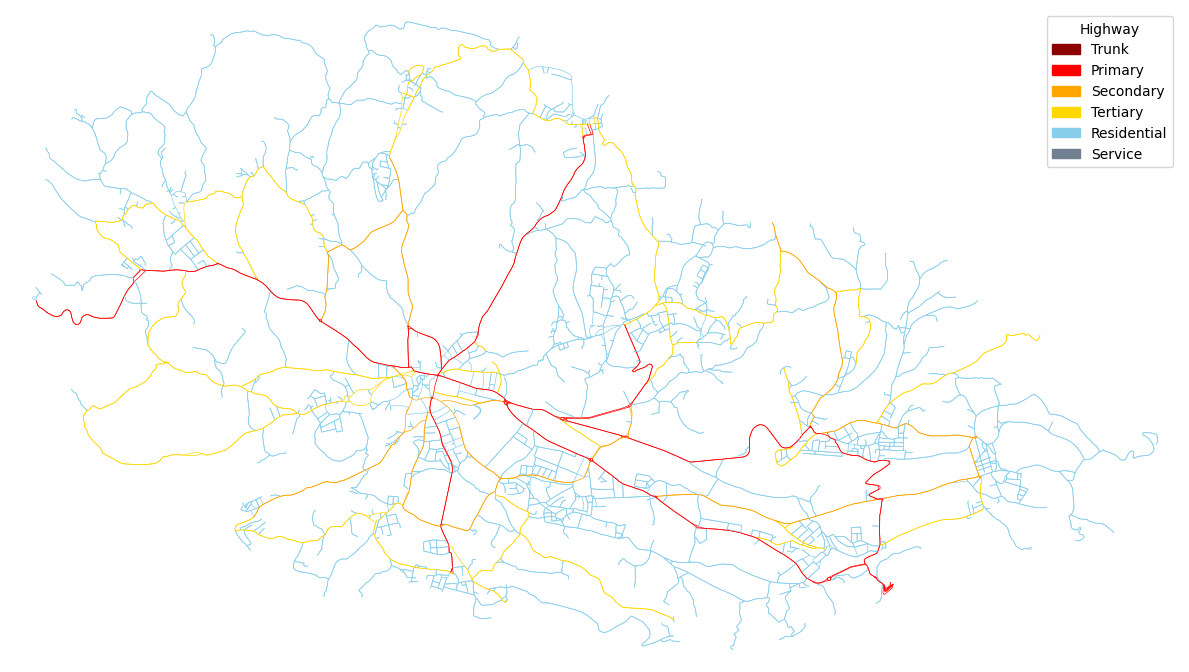

In [14]:
Plotting.plot_categorical_attr(G_drive, "highway",constants.HWY_COLORS)

## Parallel Edges

Directed node pairs: 13058
Pairs with parallel edges (>1): 0
Total extra edges beyond single-edge pairs: 0
Max parallel edges on a single pair: 1

Top pairs by parallel edges:
  (197798 -> 1497329566): 1
  (197798 -> 158611509): 1
  (197798 -> 13169274834): 1
  (197798 -> 1494342639): 1
  (1497329566 -> 1494342639): 1
  (1497329566 -> 158591473): 1
  (1497329566 -> 197798): 1
  (158611509 -> 60794838): 1
  (158611509 -> 197798): 1
  (158611509 -> 158611353): 1

Distribution (parallel_count -> number of (u,v) pairs):
  1: 13058
Parallel edge attribute comparison:


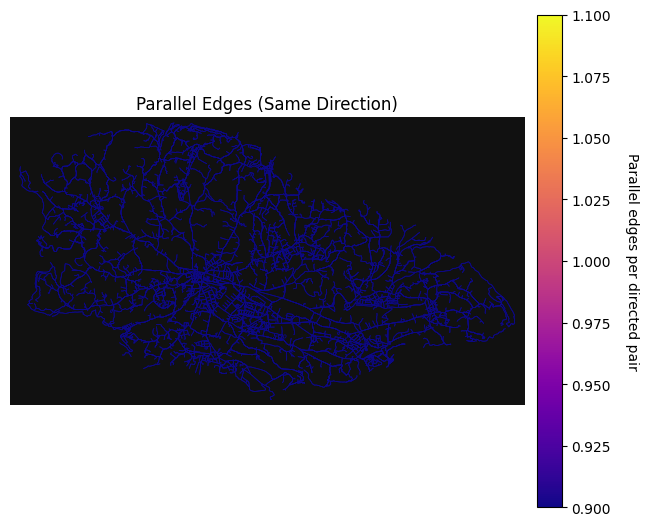

-----


In [15]:
investigation.analyze_parallel_edges(G_master)
investigation.compare_parallel_edges(G_master)
investigation.plot_parallel_edges(G_master) #TODO plotting class
print("-----")

## Reallocatability

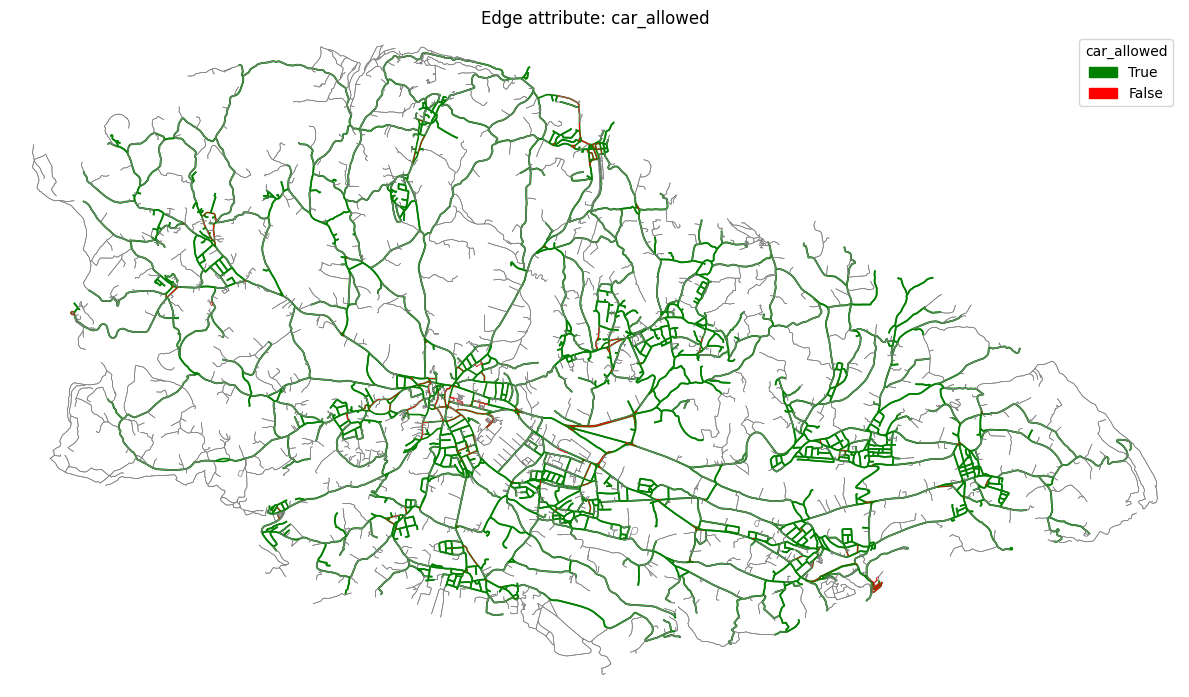

In [16]:
Plotting.plot_boolean_attribute(G_master, "car_allowed")

In [17]:
bridges = set(nx.bridges(G_master.to_undirected()))
print(len(bridges), "actual num might be double actually")

1819 actual num might be double actually


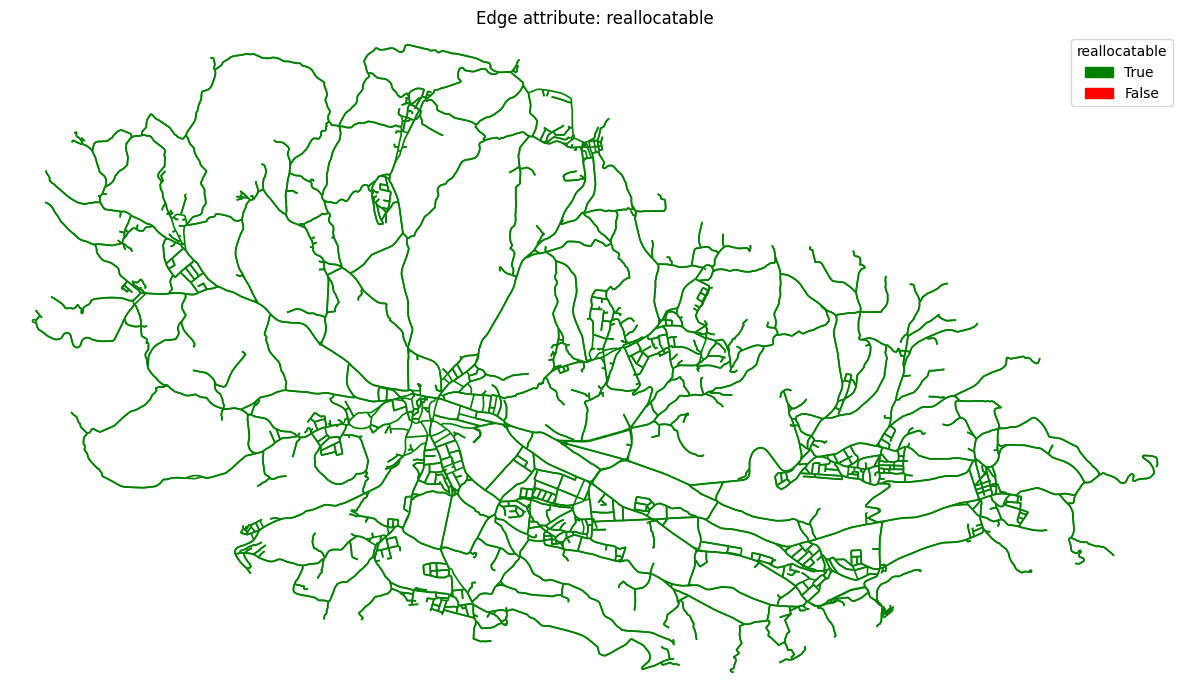

In [18]:
G_drive = graph_util.make_drive_subgraph(G_master)
Plotting.plot_boolean_attribute(G_drive, "reallocatable")

In [19]:
reallocatable_false = 0
reallocatable_true =0
for u, v, k, d in G_drive.edges(keys=True, data=True):
    if d.get("reallocatable"):
        reallocatable_true += 1
    else:
        reallocatable_false += 1

print(f"realloacable true: {reallocatable_true},", f"realloaclable false {reallocatable_false},", f"{reallocatable_true/(reallocatable_true+reallocatable_false)*100}% are reallocable")

realloacable true: 4969, realloaclable false 0, 100.0% are reallocable


(<Figure size 1200x1200 with 2 Axes>,
 <Axes: title={'center': 'Inferred Speed Limit (kph)'}>)

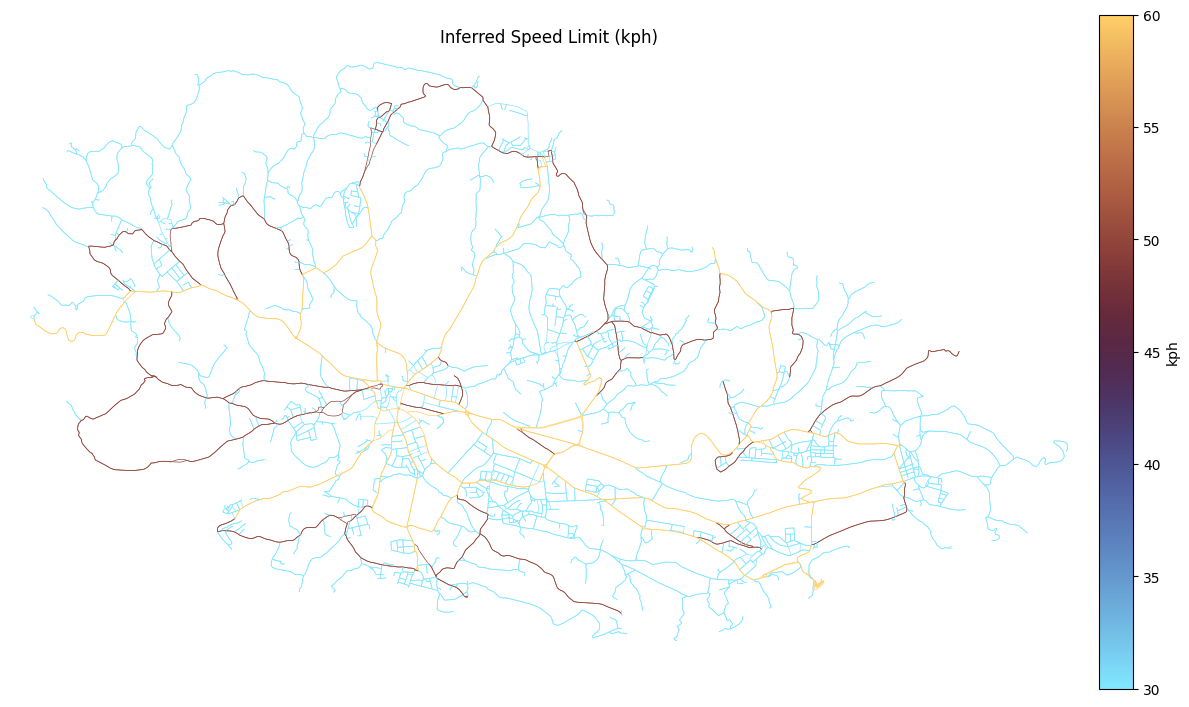

In [20]:
Plotting.plot_graph_by_edge_attr(G_drive, attr="speed_kph_current", title="Inferred Speed Limit (kph)", label = "kph")

## Topology

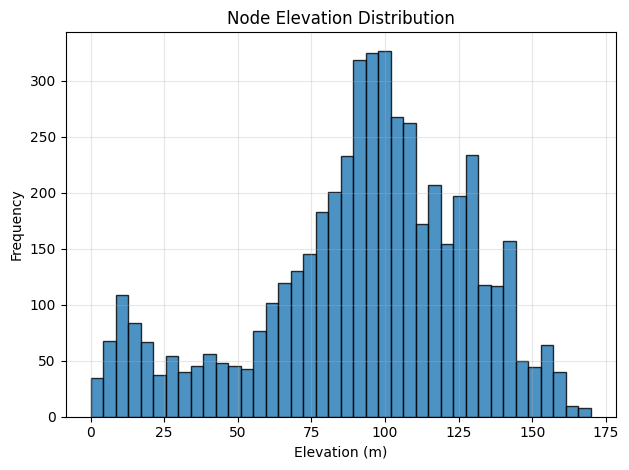

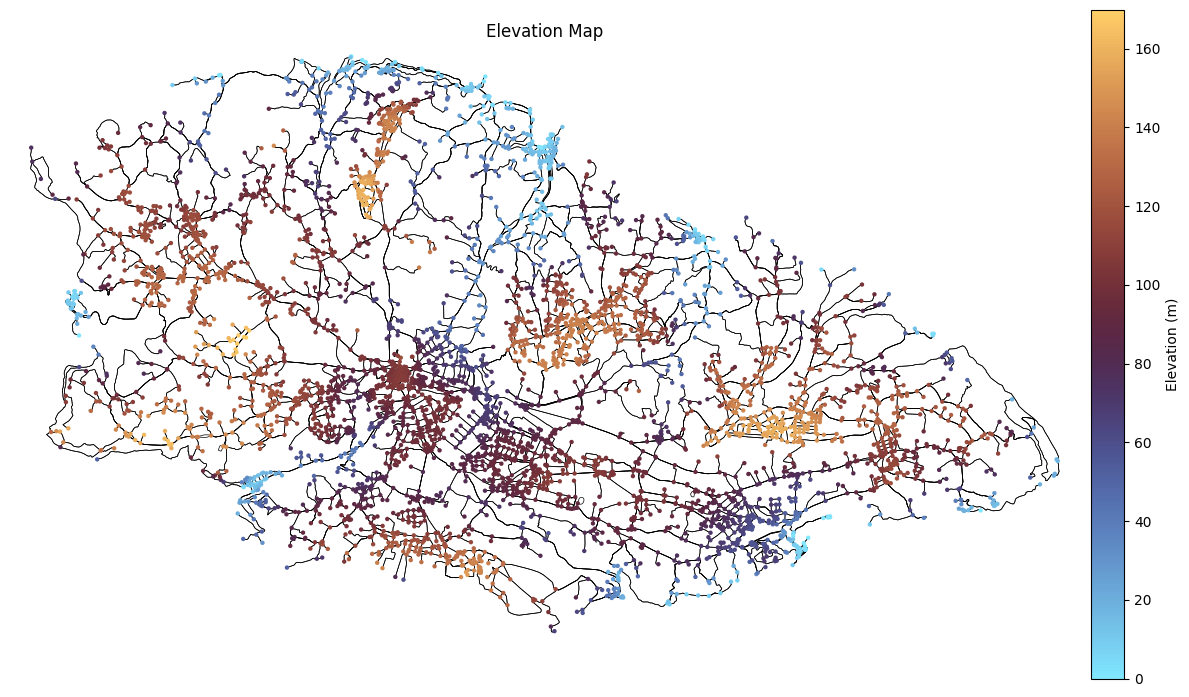

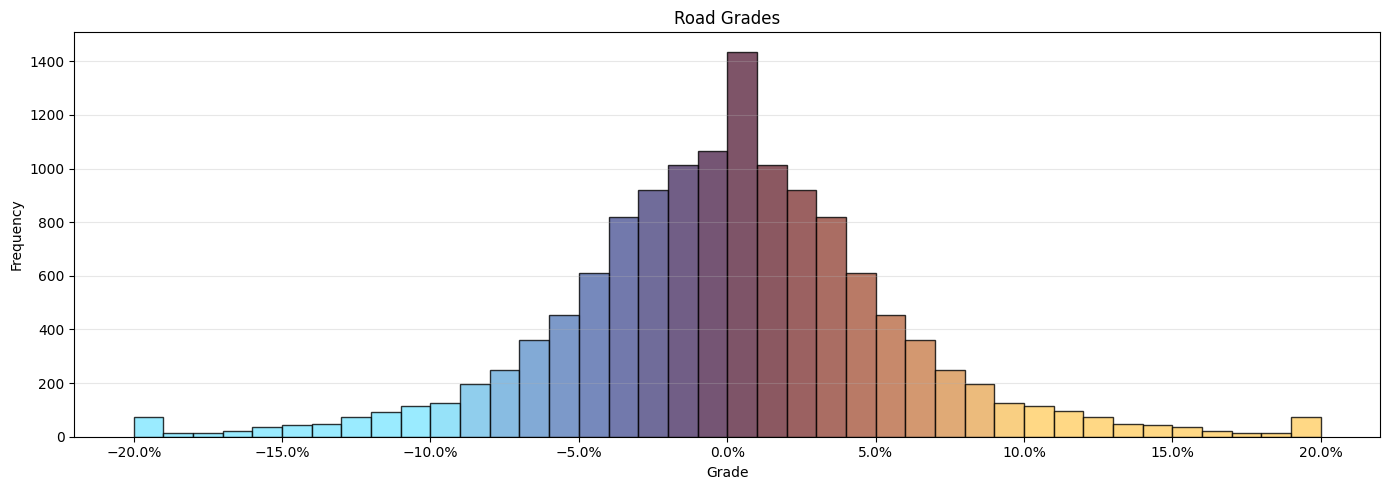

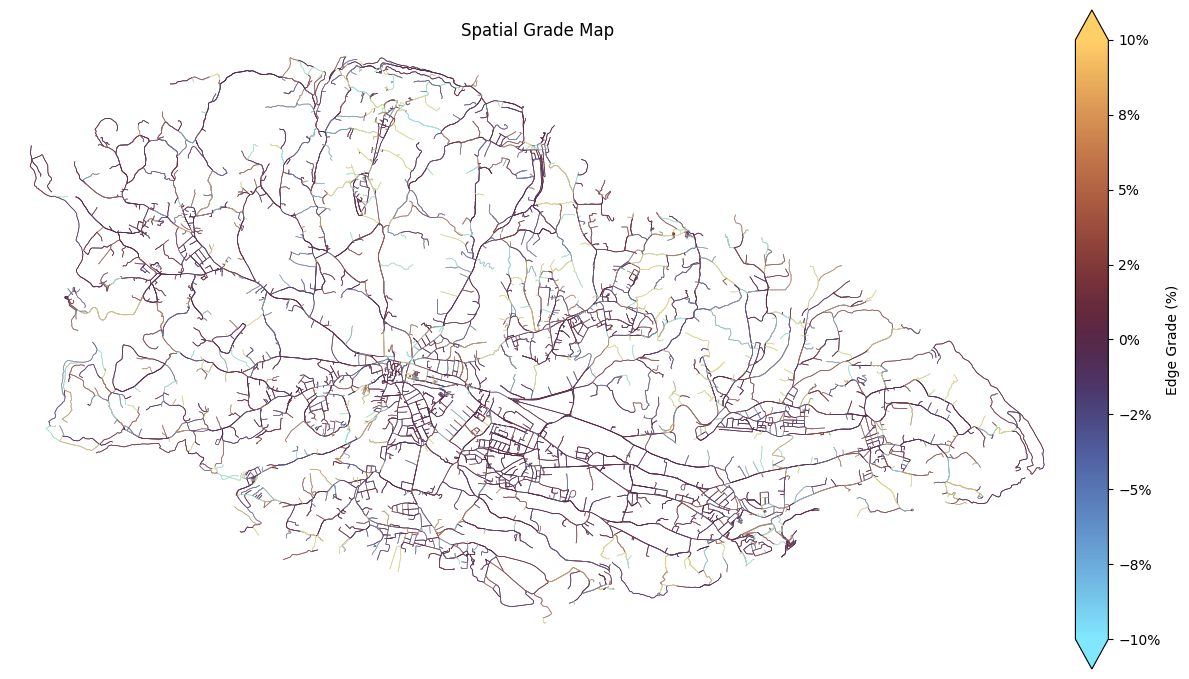

In [21]:
Plotting.plot_elevation(G_master)
Plotting.plot_grades(G_master)

## Network statistics

In [22]:
"""# what sized area does our network cover in square meters?
bike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes
graph_area_m = bike_nodes_proj.union_all().convex_hull.area
# show some basic stats about the network
stats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)"""

'# what sized area does our network cover in square meters?\nbike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes\ngraph_area_m = bike_nodes_proj.union_all().convex_hull.area\n# show some basic stats about the network\nstats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)'

In [23]:
edge_keys = set()
for u,v,data in G_master.edges(data=True):
    edge_keys.update(data.keys())
print(edge_keys)

{'grade', 'regions', 'localities', 'car_lanes', 'risk_factor', 'cycleway', 'speed_kph_current', 'grade_abs', 'bike_cost_base', 'width', 'tunnel', 'length', 'car_cost_current', 'name:en', 'name', 'bike_lanes', 'geometry', 'parallel_count', 'safety', 'reversed', 'reallocatable', 'bike_allowed', 'speed_kph', 'osmid', 'infra_type', 'bicycle', 'speed_kph_original', 'bike_cost_penalty', 'oneway', 'car_allowed', 'highway', 'bridge'}


# Generating city level subgraphs

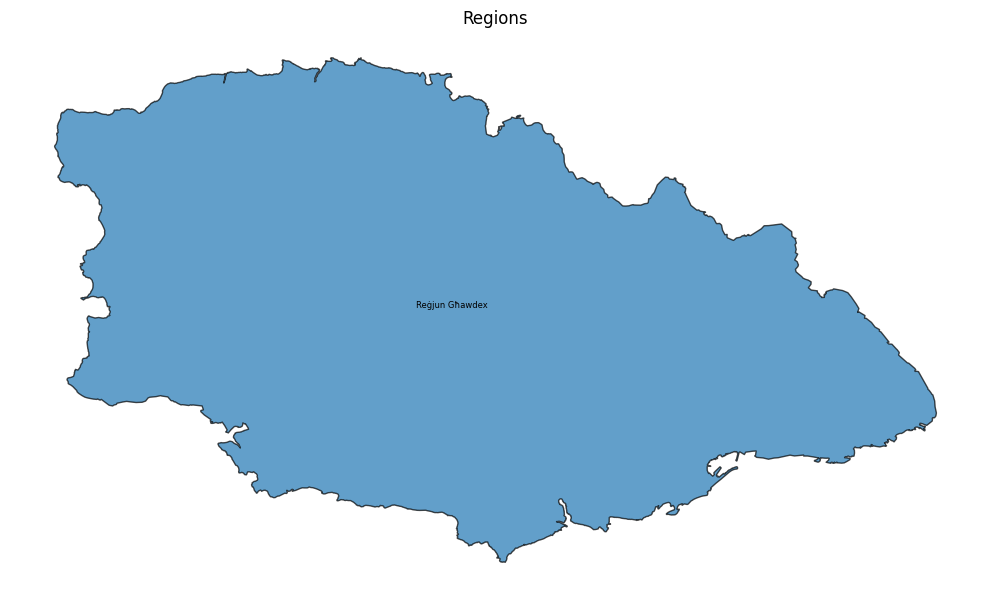

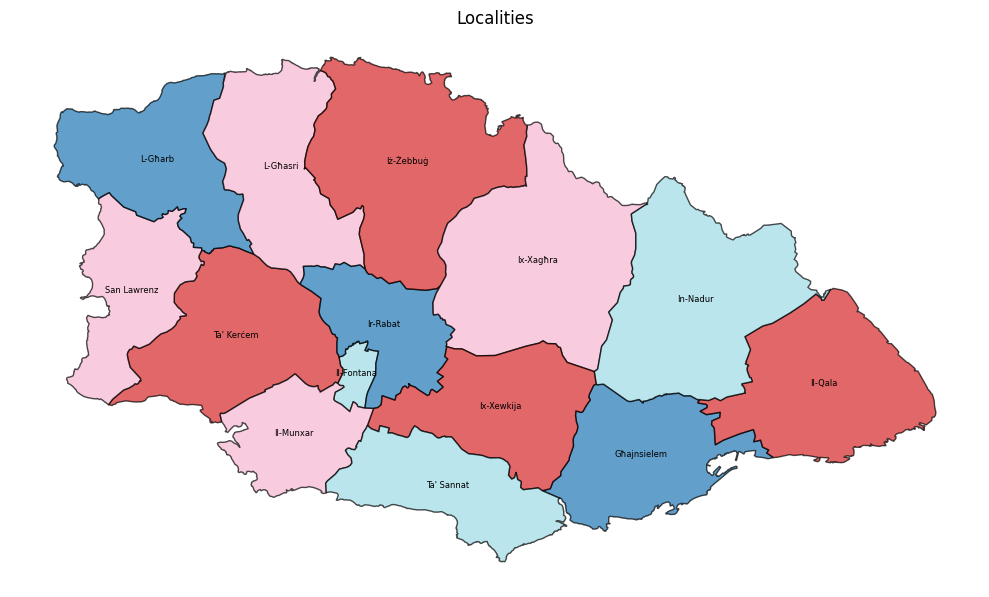

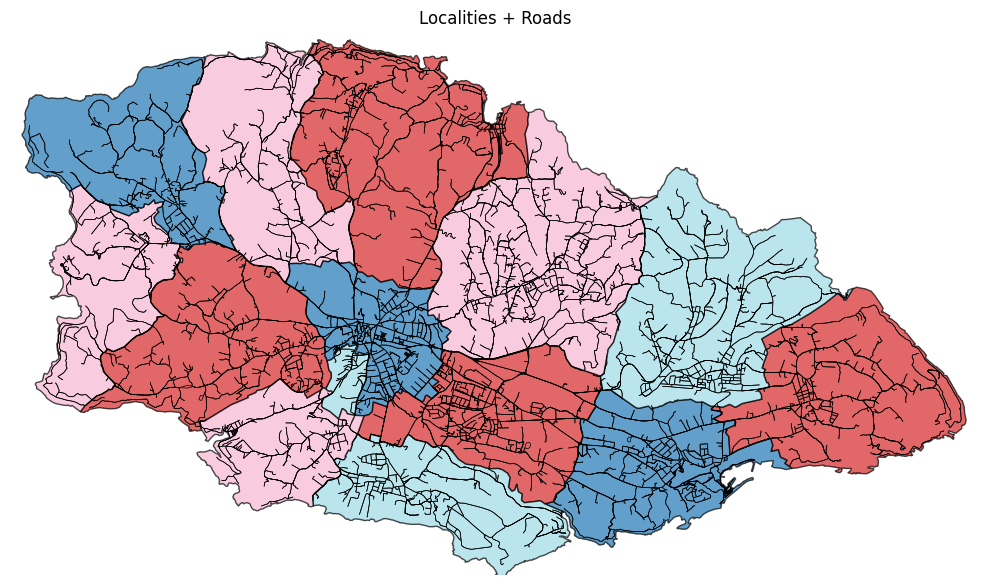

name admin_level  \
element  id                                 
relation 6311965  Għajnsielem           8   
         7508578   Il-Fontana           8   
         7508579   Ta' Kerċem           8   
         7508580  San Lawrenz           8   
         7508581      L-Għarb           8   
         7508582     L-Għasri           8   
         7508583     Ir-Rabat           8   
         7508584    Iż-Żebbuġ           8   
         7508585    Ix-Xagħra           8   
         7508586      Il-Qala           8   
         7508587     In-Nadur           8   
         7508588   Ix-Xewkija           8   
         7508589    Il-Munxar           8   
         7508590   Ta' Sannat           8   

                                                           geometry  color_id  \
element  id                                                                     
relation 6311965  POLYGON ((434495.638 3987046.719, 434497.589 3...         0   
         7508578  POLYGON ((430892.855 3988249.578, 430973.212 3...         3   
         7508579  POLYGON ((427320.748 3987916.19, 427383.682 39...         1   
         7508580  POLYGON ((427164.934 3991122.717, 427175.377 3...         2   
         7508581  POLYGON ((427164.934 3991122.717, 427138.724 3...         0   
         7508582  POLYGON ((429109.074 3992939.259, 429121.724 3...         2   
         7508583  POLYGON ((430307.991 3989805.365, 430356.354 3...         0   
         7508584  POLYGON ((430624.436 3993126.262, 430637.147 3...         1   
         7508585  POLYGON ((432492.258 3989768.61, 432577.988 39...         2   
         7508586  POLYGON ((436673.753 3987981.88, 436774.042 39...         1   
         7508587  POLYGON ((434891.936 3988432.795, 434945.042 3...         3   
         7508588  POLYGON ((431356.709 3987593.652, 431451.982 3...         1   
         7508589  POLYGON ((429084.517 3987652.785, 429073.779 3...         2   
         7508590  POLYGON ((430714.318 3986543.836, 430705.986 3...         3   

                    color  
element  id                
relation 6311965  #1f77b4  
         7508578  #9edae5  
         7508579  #d62728  
         7508580  #f7b6d2  
         7508581  #1f77b4  
         7508582  #f7b6d2  
         7508583  #1f77b4  
         7508584  #d62728  
         7508585  #f7b6d2  
         7508586  #d62728  
         7508587  #9edae5  
         7508588  #d62728  
         7508589  #f7b6d2  
         7508590  #9edae5

In [24]:
Plotting.plot_gdf_and_overlay(gdf_regions_proj, title= "Regions", annotate=True)

Plotting.plot_gdf_and_overlay(gdf_local_proj, title = "Localities", annotate=True)
Plotting.plot_gdf_and_overlay(gdf_local_proj, title="Localities + Roads", G=G_master, annotate=False)

In [25]:
subgraphs = {}
total_nodes = 0
total_edges = 0
for idx, row in gdf_local_proj.iterrows():
    name = row["name"]

    G_sub = graph_util.make_locality_subgraph(G_master, name)
    subgraphs[name] = G_sub
    total_nodes += len(G_sub.nodes)
    total_edges += len(G_sub.edges)
    print(f"✅ Created subgraph for {name}: {len(G_sub.nodes)} nodes, {len(G_sub.edges)} edges")

print(f"total_nodes{total_nodes}, total_edges{total_edges}")

✅ Created subgraph for Għajnsielem: 466 nodes, 1220 edges
✅ Created subgraph for Il-Fontana: 88 nodes, 206 edges
✅ Created subgraph for Ta' Kerċem: 436 nodes, 1029 edges
✅ Created subgraph for San Lawrenz: 201 nodes, 468 edges
✅ Created subgraph for L-Għarb: 274 nodes, 668 edges
✅ Created subgraph for L-Għasri: 277 nodes, 631 edges
✅ Created subgraph for Ir-Rabat: 653 nodes, 1710 edges
✅ Created subgraph for Iż-Żebbuġ: 563 nodes, 1410 edges
✅ Created subgraph for Ix-Xagħra: 671 nodes, 1679 edges
✅ Created subgraph for Il-Qala: 376 nodes, 921 edges
✅ Created subgraph for In-Nadur: 426 nodes, 1091 edges
✅ Created subgraph for Ix-Xewkija: 628 nodes, 1716 edges
✅ Created subgraph for Il-Munxar: 237 nodes, 570 edges
✅ Created subgraph for Ta' Sannat: 285 nodes, 717 edges
total_nodes5581, total_edges14036


# Topological Metrics

Evaluating how good a network is

In [26]:
# Directness - measures how efficiently users can travel between two point

# Centrality
#network_evaluation(graph_util.make_protected_subgraph(G_master))
## Degree - number of connections per node

# Optimisation Approaches 

## Heuristic Approaches

Centrality - betweeness and closeness

the relative ordering of nodes (or edges) is virtually identical.

Relative error → Measures absolute value difference (how far are the actual numbers).

Correlation (or Spearman’s ρ) → Measures rank consistency (how well the ordering is preserved

4994


k samples:   0%|          | 0/5 [00:00<?, ?k/s]

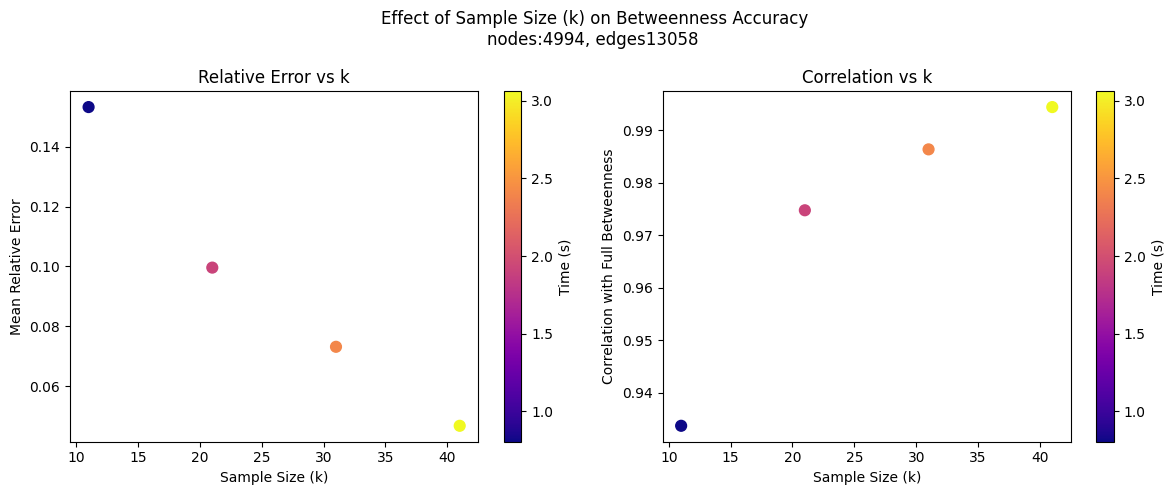

In [27]:
import time
from matplotlib import pyplot as plt
from networkx import DiGraph

#TODO move to own class?
def investigate_k_diff(G:DiGraph, max_k = None, seed=42, step=50):
    if max_k == None:
        max_k = len(G.nodes)

    edges = len(G.edges)
    #TODO this really should be k=NONE
    true_bc = nx.betweenness_centrality(G, weight="length", normalized=True, k=max_k, seed=seed)

    results = []
    iterable = range(1, max_k, step)
    for k in tqdm(iterable, desc="k samples", unit="k"):
        t0 = time.perf_counter()
        approx_bc = nx.betweenness_centrality(G, weight="length", normalized=True, k=k, seed=seed)
        elapsed = time.perf_counter() - t0

        # convert to arrays for shared nodes
        true_vals = np.array([true_bc[n] for n in G.nodes])
        approx_vals = np.array([approx_bc[n] for n in G.nodes])

        # relative mean absolute error
        rel_err = np.mean(np.abs(approx_vals - true_vals) / (true_vals + 1e-9))
        # correlation
        corr = np.corrcoef(true_vals, approx_vals)[0, 1]

        results.append((k, rel_err, corr, elapsed))
        #print(f"k={k:>5} | rel_err={rel_err:.3f} | corr={corr:.3f} | time={elapsed:.2f}s")

    ks, rel_errs, corrs, times = zip(*results)

    #TODO plotting?
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    scatter1 = ax[0].scatter(ks, rel_errs, c=times, cmap="plasma", s=60)
    ax[0].set_title("Relative Error vs k")
    ax[0].set_xlabel("Sample Size (k)")
    ax[0].set_ylabel("Mean Relative Error")
    cbar = plt.colorbar(scatter1, ax=ax[0]); cbar.set_label("Time (s)")

    scatter2 = ax[1].scatter(ks, corrs, c=times, cmap="plasma", s=60)
    ax[1].set_title("Correlation vs k")
    ax[1].set_xlabel("Sample Size (k)")
    ax[1].set_ylabel("Correlation with Full Betweenness")
    cbar2 = plt.colorbar(scatter2, ax=ax[1]); cbar2.set_label("Time (s)")

    plt.suptitle(f"Effect of Sample Size (k) on Betweenness Accuracy\nnodes:{len(G.nodes)}, edges{edges} ")
    plt.tight_layout()
    plt.show()

print(len(G_master.nodes))
investigate_k_diff(G_master,max_k=50, seed=12, step=10)

In [28]:
#%snakeviz -t
#TODO getting new very safe edges even tho nothing got allocated?
heuristics = {
    #"L2S": heuristic.heuristic_L2S,
    #"CC": heuristic.heuristic_CC,
    #"L2C": heuristic.heuristic_L2C,
    #"R2C": heuristic.heuristic_R2C,
    #"Random": heuristic.heuristic_random,
    "edge_betweenness": heuristic.heuristic_edge_betweenness_centrality,
    #"edge_closeness_centrality": heuristic.heuristic_edge_closeness_centrality,
}

#chosen_localities = {"Birkirkara", "Il-Birgu"}  # use set for fast membership
#subgraphs = {name: G for name, G in subgraphs.items() if name in chosen_localities}

#NOTE majority of computation time is spent on evaluation 
all_results = []
for name, func in heuristics.items():
    print(f"Running {name} heuristic")
    df = graph_optimisation_heuristic.run_global(
        G_master,
        heuristic_func=func,
        n_iterations=100,
        max_workers=7,
        EVALUATION_MOD=10,
        k_sample = 25, 
        parallel=False,
    )
    df["heuristic"] = name
    all_results.append(df)

optimised_graph_results_df = pd.concat(all_results, ignore_index=True)
optimised_graph_results_df.sort_values(by=["heuristic", "locality", "iteration"])
optimised_graph_results_df.head()

Running edge_betweenness heuristic


Processing localities:   0%|          | 0/1 [00:00<?, ?loc/s]

🏙️ Starting MASTER in process


Iterations (MASTER):   0%|          | 0/100 [00:00<?, ?iter/s]

(261696341, 160157229, 0)


KeyError: 'car_cost_if_fietsstraat'

In [ ]:
"""%snakeviz -t df=graph_optimisation.run_global(G_master, subgraphs, heuristic_func=heuristic.heuristic_edge_betweenness_centrality, n_iterations=5, max_workers=7, EVALUATION_MOD=5, k_sample = 50,  parallel=False)"""

'%snakeviz -t df=graph_optimisation.run_global(G_master, subgraphs, heuristic_func=heuristic.heuristic_edge_betweenness_centrality, n_iterations=5, max_workers=7, EVALUATION_MOD=5, k_sample = 50,  parallel=False)'

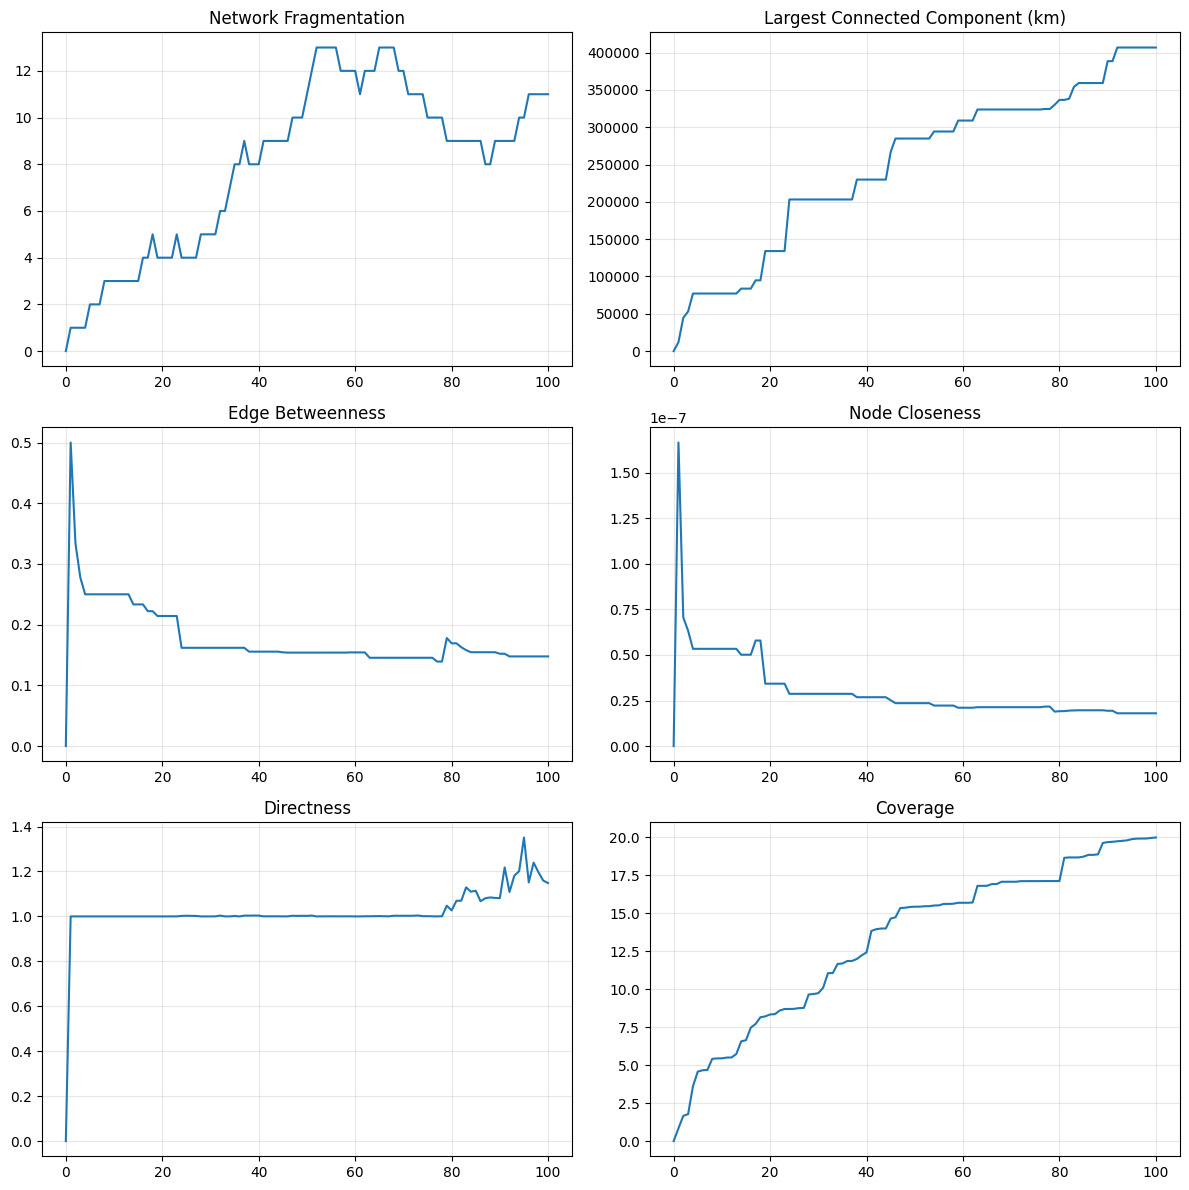

In [ ]:
chosen_heuristic = 'edge_betweenness'
chosen_locality = "MASTER"

optimised_locality_heuristic_df = optimised_graph_results_df[
    (optimised_graph_results_df['heuristic'] == chosen_heuristic) &
    (optimised_graph_results_df['locality'] == chosen_locality)
]
Plotting.plot_metrics(optimised_locality_heuristic_df)

In [ ]:
#G_locality= graph_util.make_locality_subgraph(G_master,chosen_locality)
#plotting.plot_directionality(G_master)

In [ ]:
edges = list(G_master.edges(keys=True, data=True))
u, v, k, data = edges[0]
print(u, v, k)
display(data)

197798 1497329566 0


{'osmid': [139266489, 1182920597],
 'oneway': True,
 'highway': 'primary',
 'name': 'Triq l-Imġarr',
 'name:en': 'Mġarr Road',
 'reversed': False,
 'length': np.float64(8402692.93419991),
 'geometry': <LINESTRING (435890.692 3986839.052, 435904.483 3986833.56, 435927.949 39868...>,
 'car_allowed': True,
 'bike_allowed': False,
 'grade': -0.038010328418853705,
 'grade_abs': 0.038010328418853705,
 'speed_kph': 60.0,
 'speed_kph_original': 60.0,
 'speed_kph_current': 60.0,
 'car_lanes': 1,
 'bike_lanes': 1,
 'infra_type': 'car',
 'safety': <SafetyClass.DANGEROUS: 'dangerous'>,
 'risk_factor': 4.0,
 'bike_cost_base': np.float64(1508520.5071319938),
 'bike_cost_penalty': np.float64(6034082.028527975),
 'car_cost_current': np.float64(504161.5760519946),
 'car_cost_if_fietsstraat': np.float64(1008323.1521039892),
 'reallocatable': False,
 'regions': ['Reġjun Għawdex'],
 'localities': ['Għajnsielem'],
 'parallel_count': 1,
 'edge_importance': 9,
 'edge_importance_log': np.float64(2.30258509299

In [ ]:
missing = [(u, v, k) for u, v, k, d in G_master.edges(keys=True, data=True) if d.get("width") is None]
print("Edges without width:", len(missing), "/", G_master.number_of_edges(), f"({100*len(missing)/G_master.number_of_edges():.2f}%)")
# show up to 10 examples
print("Examples:", missing[:10])

Edges without width: 12974 / 13058 (99.36%)
Examples: [(197798, 1497329566, 0), (197798, 158611509, 0), (197798, 13169274834, 0), (197798, 1494342639, 0), (1497329566, 1494342639, 0), (1497329566, 158591473, 0), (1497329566, 197798, 0), (158611509, 60794838, 0), (158611509, 197798, 0), (158611509, 158611353, 0)]


In [ ]:
G_master[4552382185][1534377155][0]

{'osmid': 1285629834,
 'oneway': False,
 'highway': 'secondary',
 'reversed': True,
 'length': np.float64(495035.85579473013),
 'geometry': <LINESTRING (437817.93 3988021.86, 437815.845 3988022.562, 437813.639 398802...>,
 'car_allowed': True,
 'bike_allowed': False,
 'grade': -0.0285125315543621,
 'grade_abs': 0.0285125315543621,
 'speed_kph': 60.0,
 'speed_kph_original': 60.0,
 'speed_kph_current': 60.0,
 'car_lanes': 1,
 'bike_lanes': 1,
 'infra_type': 'car',
 'safety': <SafetyClass.DANGEROUS: 'dangerous'>,
 'risk_factor': 4.0,
 'bike_cost_base': np.float64(91205.65851031116),
 'bike_cost_penalty': np.float64(364822.63404124463),
 'car_cost_current': np.float64(29702.151347683804),
 'car_cost_if_fietsstraat': np.float64(59404.30269536761),
 'reallocatable': False,
 'regions': ['Reġjun Għawdex'],
 'localities': ['Il-Qala'],
 'parallel_count': 1,
 'edge_importance': 11,
 'edge_importance_log': np.float64(2.4849066497880004)}

[{'edge': (261696341, 160157229, 0)},
 {'edge': (160157229, 261696341, 0)},
 {'edge': (160157229, 160157238, 0)},
 {'edge': (160157238, 160157229, 0)},
 {'edge': (160157238, 160166055, 0)},
 {'edge': (160166055, 160157238, 0)},
 {'edge': (160166055, 1546011180, 0)},
 {'edge': (1546011180, 160166055, 0)},
 {'edge': (3467074798, 3467074796, 0)},
 {'edge': (3467074796, 3467074798, 0)},
 {'edge': (3467074796, 3334086426, 0)},
 {'edge': (3334086426, 3467074796, 0)},
 {'edge': (3334086426, 153218912, 0)},
 {'edge': (153218912, 3334086426, 0)},
 {'edge': (322591541, 5061938464, 0)},
 {'edge': (5061938464, 322591541, 0)},
 {'edge': (153218912, 156216851, 0)},
 {'edge': (156216851, 153218912, 0)},
 {'edge': (5061938464, 5061940425, 0)},
 {'edge': (5061940425, 5061938464, 0)},
 {'edge': (5061940425, 899409451, 0)},
 {'edge': (899409451, 5061940425, 0)},
 {'edge': (899409451, 160157782, 0)},
 {'edge': (160157782, 899409451, 0)},
 {'edge': (160157782, 160157247, 0)},
 {'edge': (160157247, 16015778

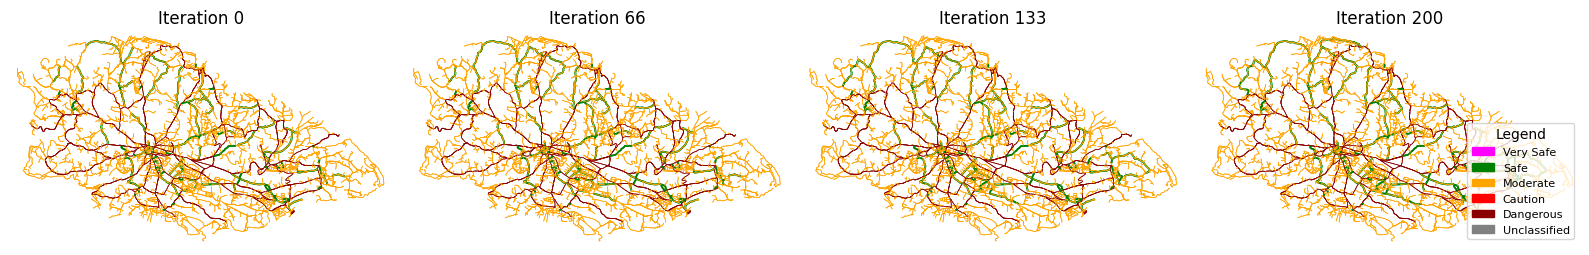

In [ ]:
diff_log_series = optimised_locality_heuristic_df["diff_log"]
diff_log = diff_log_series.explode().dropna().tolist()
display(diff_log)
#plotting.plot_snapshots(graph_util.make_bikeable_subgraph(G_master), diff_log, num_snapshots=4, show_classification=False)
Plotting.plot_snapshots(G_master, diff_log, num_snapshots=4, show_classification=True)


#TODO there seems to be multiple edges beneath each other?

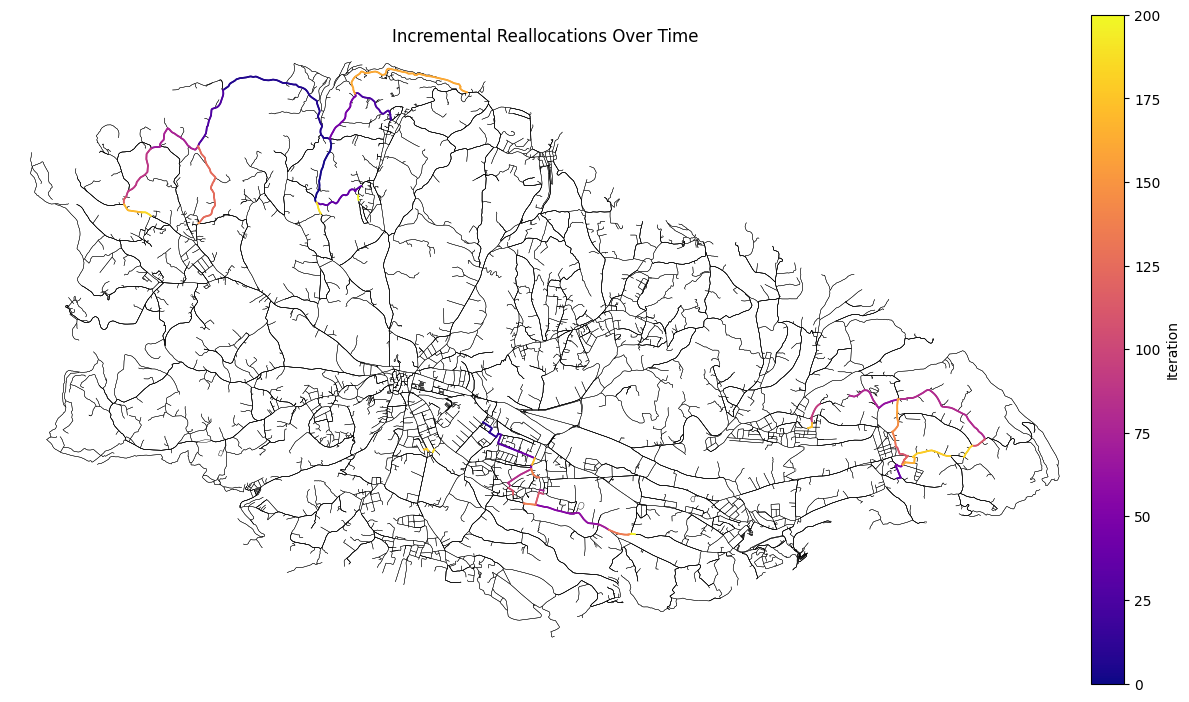

In [ ]:
Plotting.plot_network_evolution(G_master, diff_log)

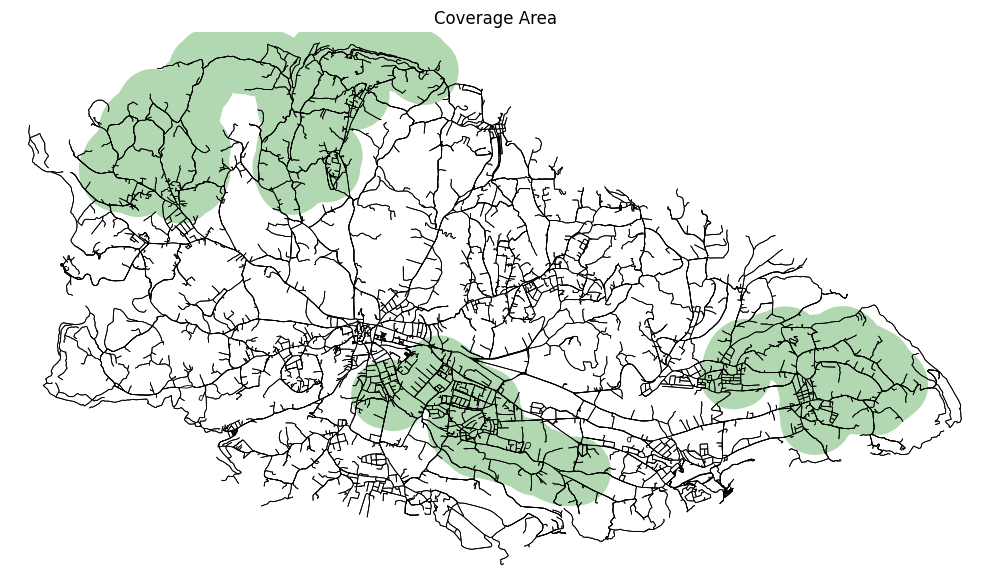

In [ ]:
union_geom = optimised_locality_heuristic_df["union_geom"].iloc[-1]
Plotting.plot_coverage(G_master, union_geom)

# OD Matrix Generation

Origin and Destination valid sample region and points

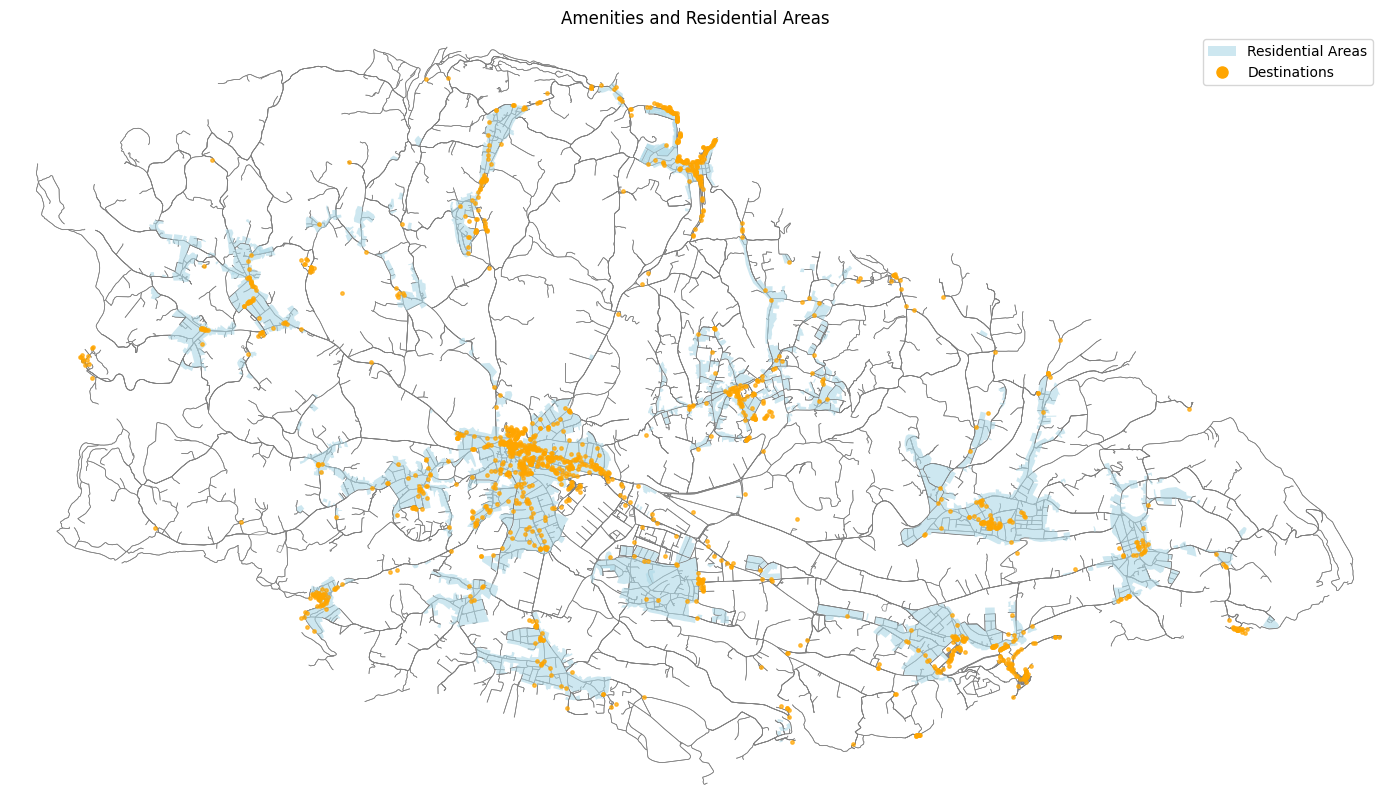

In [29]:
# https://wiki.openstreetmap.org/wiki/Key:amenity
gdf_destinations = ox.features_from_place(
    LOCATION,
    tags={    
        "amenity": True,   # schools, hospitals, cafes, etc.
        "shop": True,      # retail, services, supermarkets, etc.
        "office": True     # workplaces (IT, government, companies, etc.)
        }
)

gdf_residential = ox.features_from_place(
    LOCATION,
    tags={"landuse": "residential"}
)

gdf_destinations = gdf_destinations.to_crs(G_master.graph["crs"])
gdf_destinations = ODGeneration.prepare_destinations_with_weights(gdf_destinations, ODGeneration.DESTINATION_WEIGHTS)
gdf_residential = gdf_residential.to_crs(G_master.graph["crs"])


Plotting.plot_OD_points(
    G_master,
    gdf_residential=gdf_residential,
    gdf_destinations=gdf_destinations,
    title="Amenities and Residential Areas",)


- Sample origins from residential areas (weighted by area or building count)
- Sample destinations from amenities (weighted by amenity type)
- Apply cycling feasibility constraint (distance cutoff or decay)
- Repeat X times to build OD flows

- Add secondary pure random trips

Investigating the different amenities and their frequency

In [30]:
gdf_destinations.head()

print("dest_type:")
display(gdf_destinations["dest_type"].value_counts())

print("dest_subtype:")
display(gdf_destinations["dest_subtype"].value_counts())

dest_type:


dest_type
amenity    1161
shop        261
office       20
Name: count, dtype: int64

dest_subtype:


dest_subtype
bench                      358
restaurant                 159
parking                     99
waste_basket                71
place_of_worship            46
                          ... 
college                      1
prison                       1
agrarian                     1
educational_institution      1
clinic                       1
Name: count, Length: 133, dtype: int64

Example of sampling a single OD point

geometry dest_type  \
element id                                                     
node    156206003    POINT (431788.823 3987178.43)   amenity   
        158646190   POINT (436673.017 3988079.598)   amenity   
        160284765    POINT (430280.84 3987902.254)   amenity   
        171167035   POINT (429793.545 3992105.272)   amenity   
        261695222   POINT (432584.026 3988673.552)   amenity   
...                                            ...       ...   
way     1455497043  POINT (434410.625 3988420.713)   amenity   
        1455956907   POINT (437279.77 3987907.182)   amenity   
        1457346211  POINT (433727.622 3987930.872)      shop   
        1457371865  POINT (436593.425 3986915.469)   amenity   
        1457371867  POINT (435826.616 3986906.894)   amenity   

                        dest_subtype  weight  
element id                                    
node    156206003   place_of_worship     1.0  
        158646190         restaurant     2.0  
        160284765         biergarten     1.0  
        171167035            parking     1.0  
        261695222               fuel     1.0  
...                              ...     ...  
way     1455497043           parking     1.0  
        1455956907           shelter     1.0  
        1457346211           chemist     1.0  
        1457371865           parking     1.0  
        1457371867           parking     1.0  

[1442 rows x 4 columns]

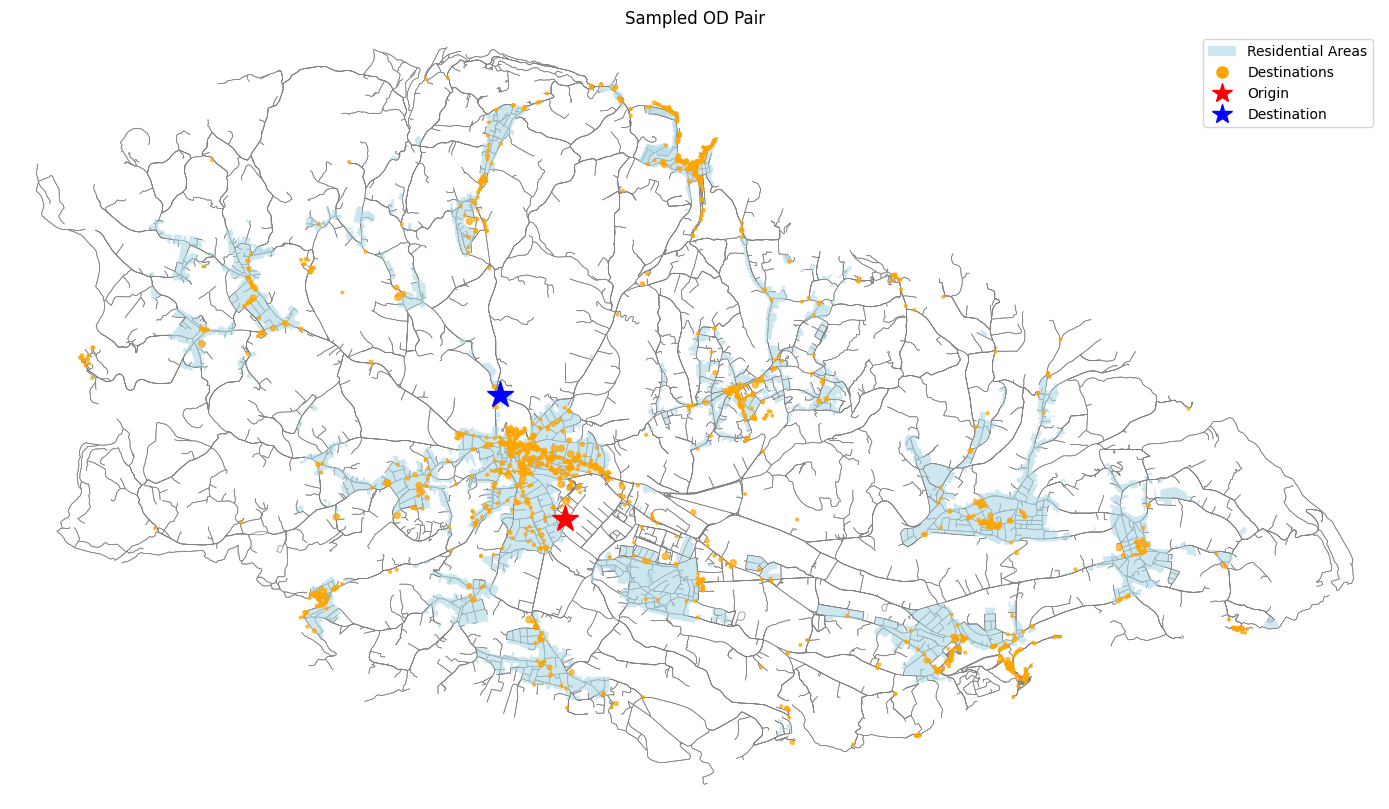

[3455263052,
 156215159,
 5319686958,
 12578573179,
 156214186,
 156214077,
 324401043,
 158583290,
 324401034,
 259225537,
 263685286,
 158583287,
 158582584,
 325699166,
 197824,
 5056025341,
 264860081,
 2835429265,
 2835429266,
 264857690,
 5342623823,
 263685599,
 158575465,
 156195297,
 171157063,
 325756621,
 197844,
 3861497227,
 12012549460,
 3861497204]

In [31]:
origin_pt = ODGeneration.sample_point_from_regions_weighted(gdf_residential, rng)


display(gdf_destinations)

destination_pt = ODGeneration.sample_destination_gravity(origin_pt, gdf_destinations, rng)

# Plot the point on the graph
Plotting.plot_OD_points( 
    G_master,
    gdf_residential=gdf_residential,
    gdf_destinations=gdf_destinations,
    destination_size_col="weight",
    origin_point=origin_pt,
    destination_point=destination_pt,
    title="Sampled OD Pair",
)

origin_node = ox.distance.nearest_nodes(
            G_master, origin_pt.x, origin_pt.y
        )
dest_node = ox.distance.nearest_nodes(
            G_master, destination_pt.x, destination_pt.y
        )

path_nodes = nx.shortest_path(G_master, origin_node, dest_node, weight="car_cost_current")
display(path_nodes)


## Full OD matrix Generation and Analysis

In [32]:
od = ODGeneration.gen_OD_trips(G_master, gdf_residential, gdf_destinations, rng, n_trips=1_000, random_frac=.1)
paths = paths_util.compute_candidate_paths(G_master, od, "car_cost_current")
edge_importance = paths_util.compute_edge_importance(G_master, paths)

(<Figure size 1200x1200 with 2 Axes>,
 <Axes: title={'center': 'Log edge_importance'}>)

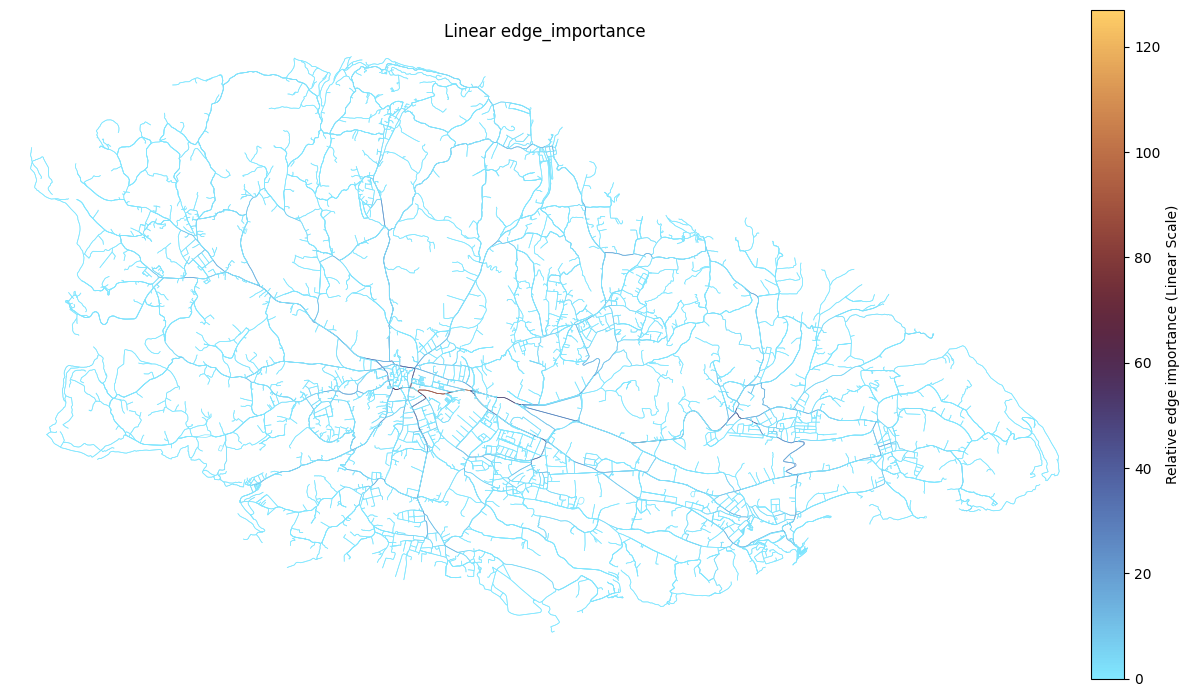

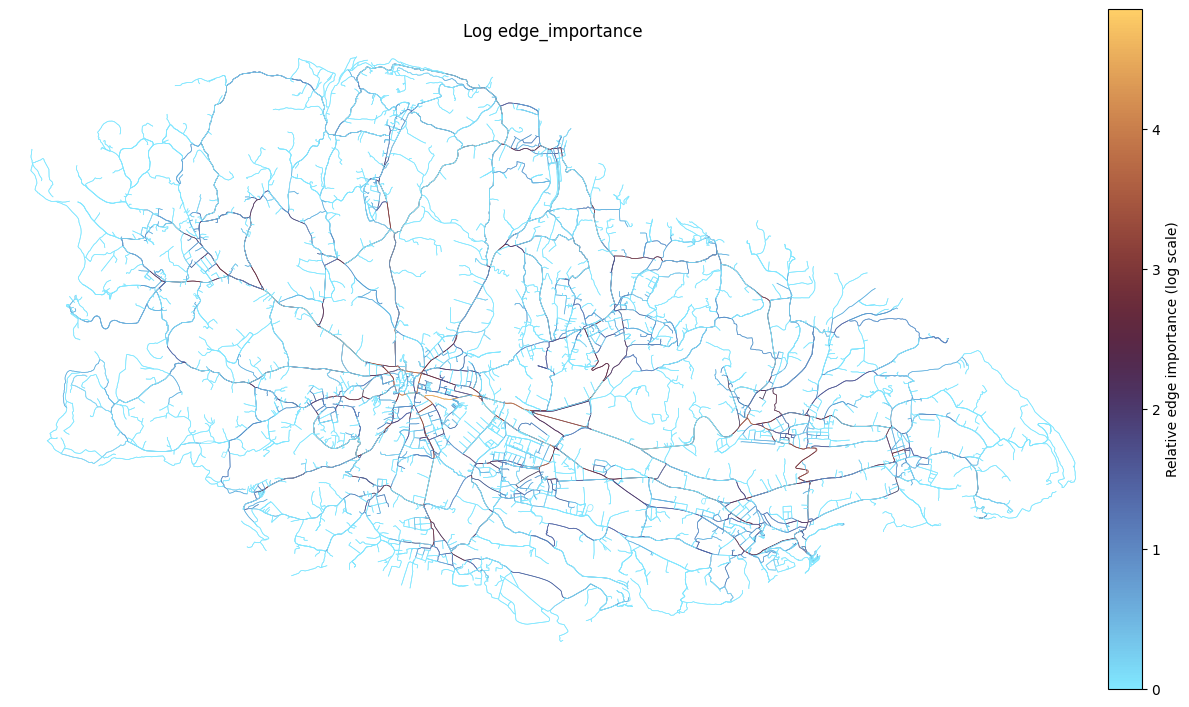

In [33]:
# 1. Initialize attribute for ALL edges
for u, v, k in G_master.edges(keys=True):
    G_master[u][v][k]["edge_importance"] = 0.0

# 2. Assign computed importance values
for (u, v, k), val in edge_importance.items():
    G_master[u][v][k]["edge_importance"] = val

for u, v, k in G_master.edges(keys=True):
    val = G_master[u][v][k]["edge_importance"]
    G_master[u][v][k]["edge_importance_log"] = np.log1p(val)

Plotting.plot_graph_by_edge_attr(G_master, attr="edge_importance", cmap="managua_r", title="Linear edge_importance", label="Relative edge importance (Linear Scale)")

#NOTE Edge importance shown on a logarithmic colour scale to improve readability.
#NOTE Analyse and report edge importance in linear space; use log-scaled importance exclusively for visualisation to reveal network structure.
Plotting.plot_graph_by_edge_attr(
    G_master,
    attr="edge_importance_log",
    cmap="managua_r",
    title="Log edge_importance",
    label="Relative edge importance (log scale)"
)


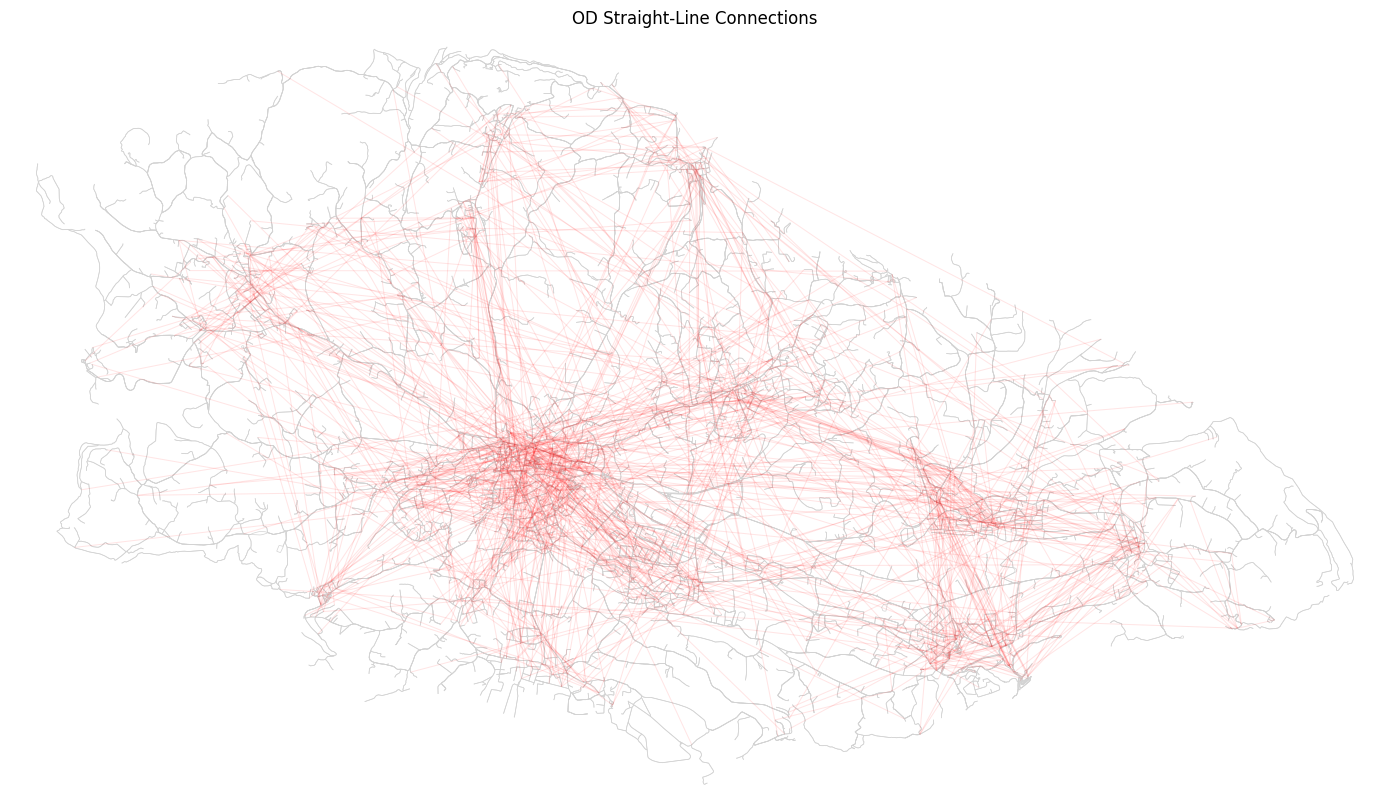

,weight,geometry
0,1,"LINESTRING (437810.023 3988253.59, 436709.19 3..."
1,1,"LINESTRING (431685.634 3988866.668, 430482.214..."
2,1,"LINESTRING (435679.079 3988995.274, 437763.146..."
3,1,"LINESTRING (430982.101 3987330.703, 432127.251..."
4,1,"LINESTRING (432737.161 3987592.491, 431660.714..."
...,...,...
1088,1,"LINESTRING (431361.414 3986945.137, 430245.925..."
1089,1,"LINESTRING (437770.591 3988481.097, 428278.98 ..."
1090,1,"LINESTRING (433358.385 3991295.755, 431680.66 ..."
1091,1,"LINESTRING (434694.126 3987801.476, 430895.039..."


In [34]:
Plotting.plot_OD_lines(
    G_master,
    od,
    alpha=0.1,
    linewidth=1.5,
    title="OD Straight-Line Connections",
)


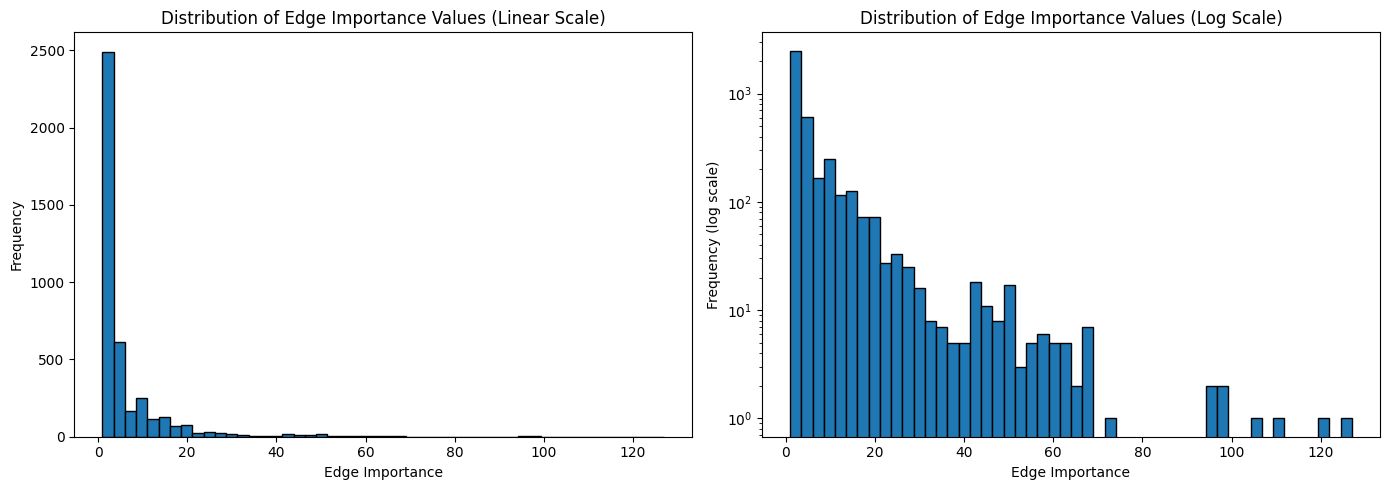

[  1.     1.     2.     6.    15.    22.    52.42 127.  ]


In [35]:
import matplotlib.pyplot as plt

vals = list(edge_importance.values())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax[0].hist(vals, bins=50, edgecolor='black')
ax[0].set_xlabel('Edge Importance')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of Edge Importance Values (Linear Scale)')

# Log scale
ax[1].hist(vals, bins=50, edgecolor='black')
ax[1].set_xlabel('Edge Importance')
ax[1].set_ylabel('Frequency (log scale)')
ax[1].set_title('Distribution of Edge Importance Values (Log Scale)')
ax[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Show percentiles
print(np.percentile(vals, [0, 25, 50, 75, 90, 95, 99, 100]))
# Show percentiles

## OD allowed arcs

In [36]:
import random
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt

def plot_corridor_size_distribution(od_allowed_arcs, OD, *, bins=40):
    """Histogram of |allowed arcs| across ODs."""
    sizes = [len(od_allowed_arcs.get(p, set())) for p in range(len(OD))]
    plt.figure()
    plt.hist(sizes, bins=bins)
    plt.title("OD corridor size distribution (allowed arcs per OD)")
    plt.xlabel("Allowed arcs count")
    plt.ylabel("Number of ODs")
    plt.show()


In [37]:
seg_to_arcs, arc_to_seg, G_seg = graph_structure.build_segment_graph(G_master)

In [38]:
#TODO there really shouldnt be overlapping green and red edges
fig, ax = Plotting.plot_od_allowed_corridor(
    G=G_master,
    G_seg=G_seg,
    OD_list=od,
    od_idx=3,
    seg_to_arcs=seg_to_arcs,
    arc_to_seg=arc_to_seg,
    corridor_hops=2,
    node_size = 2,
    fig_size = (30,30)
)

AttributeError: 'tuple' object has no attribute 'origin'

# Mathematical Solver

Solver

TODO:
- Modelling
    - Your current method is: Path-based + Edge-local
    - Wiedemann is: Flow-based + Global rerouting
- Seperate breakdown for main roads and side streets?
- All the other relexxations? (such as fixing roads)
- Planners could incorporate Sheng Liu’s General Utility (GU) function—which rewards the size of continuous segments—directly into Wiedmann’s multi-criteria objective functio

- Do some seperate logic for main roads to allow for whole dedicated bike lanes instead of fietsstraat?


- allow for direction changing of cars


Known Limitations:
- Number of lanes is not considered for travel time, and reallocation cost, since congestion is not being simulated explicitly. Techinically I could create some 'friction' factor were if there a multiple lanes, than conversion to fietsstraat,creates more 'friction'



idk man: 
- so wiedmann seperated the main road and side street solve, so that he could parrallelise across different cities. Since main roads cross across many cities. 

- I could technincally do different logic for this main road where i can build dedicated bike segments instead of fietstraatt.

- Note i considered an approach where we would have flow for dedicated car ,dedicated bike, fieetstrrat and shared bike guests, but this would make the decisions too complex for the solver

Conclusions:
- if im going to do the parrallelisation (i prob am), ig i should do the seperate dedicated logic but this complicates stuff? but tbh the realism is needed.

- if im doing it all in one pass, i can just feed the solver my special logic, and it wouldn't know its special it just picks from the options i give it.

conclusion's conclusion:
- I want to go for all in one pass, but i dont think its computaitonally possible for malta

Methodology:

**City-wide lane reallocation process in Wiedemann et al.**

The city-scale lane reallocation framework proposed by Wiedemann et al. follows a structured, multi-stage optimisation workflow designed to remain tractable for large urban networks.

1. Network extraction and preprocessing
The street network is extracted from OpenStreetMap (OSM) and represented as a graph with edges annotated by length, gradient, speed limit, and lane capacity. Infrastructure that cannot be modified, such as highways or tram corridors, is fixed and excluded from reallocation.

1. Lane-level graph construction
The base undirected street graph is converted into a directed multigraph to enable direction-specific and lane-level capacity allocation. This representation allows lanes to be reassigned between car and bicycle use independently in each direction.

1. Definition of travel-time impedance
Car travel time is computed from distance and speed limits, while bicycle travel time incorporates additional penalties reflecting perceived safety, gradient, and riding on non-protected (car) infrastructure.

1. Demand representation
Rather than an all-pairs formulation, the model uses a demand-driven origin–destination (OD) set to limit computational complexity while capturing dominant travel flows across the city.

1. Separation of main and non-main roads
The network is divided into main roads and non-main roads. This separation reduces problem size and ensures that the primary car network is treated more conservatively during lane reallocation.

1. Partitioning into independent regions
Main roads are partitioned into five large regions, while non-main roads are partitioned into 57 smaller regions, resulting in 62 regional optimisation problems.

1. Iterative LP-based lane allocation (per region)

    For each region, an iterative optimisation procedure is applied:

    - solve a linear program with relaxed lane-allocation variables,

    - fix the largest or most decisive lane allocations,

    - re-solve the LP with a reduced decision space,

    - repeat until convergence or until any further bicycle-lane allocation would disconnect the regional car network.

1. Parallel execution
Each regional optimisation problem is solved independently. These instances are executed in parallel using Python’s multiprocessing framework, substantially reducing total runtime.

1. City-wide solution assembly
The regional lane-allocation results are merged to form a consistent city-wide lane reallocation plan, specifying which lanes are dedicated to bicycles and which remain available for cars in each direction.

1. Evaluation of final network performance
The resulting network is evaluated using bicycle and car travel-time metrics under the defined OD demand, and alternative policy scenarios are explored by varying the objective-function weights.


**Methodology Mine**

1. Repeat until budget is spent:
1. Compute bike shortest paths on current bike weights
1. Compute car shortest paths on current car weights
1. Solve a locality-constrained edge selection problem for a small batch k_batch
1. Apply the selected reallocations to the master graph
1. Recompute costs (bike and car) for affected edges
1. Loop

In [39]:
# By solving in multiple batches, we reduce computation time
#TODO CHatGPT is not agreeing, saying that recalculting the OD paths is way more expensive and takes the most time. And that my formulation is actually quite simple????


In [41]:
# Build LP inputs for lane-level rounding,
eligible_bike_arcs = set(graph_util.make_reallocatable_subgraph(G_master).edges(keys=True))
main_arcs = set(graph_util.make_highway_subgraph(G_master, "primary").edges(keys=True))
lambda_seg = {
    seg: max(1.0, sum(float(G_master[u][v][k].get("car_lanes", 1.0)) for (u, v, k) in arcs))
    for seg, arcs in seg_to_arcs.items()
}

od_weighted = ODGeneration.scale_OD_pairs(od, bike_share=0.1)
od_weighted = ODGeneration.append_auxiliary_chain_od_pairs(od_weighted, rng, list(G_master.nodes()))

seed_segs, arcs_corr, od_allowed = paths_util.build_od_allowed_arcs(
    G=G_master,
    G_seg=G_seg,
    OD_list=od_weighted,
    seg_to_arcs=seg_to_arcs,
    arc_to_seg=arc_to_seg,
    corridor_hops=50,
    include_car_path=True,
    include_bike_path=True,
)



TODO
Second mismatch: you are forcing the same OD demand for cars and bikes
- auxilery paths?
- check if my OD pair change broke somehting somwhere

---------
So:

ω-weighting = “importance weighting” (priority in objective)

RHS scaling = “volume weighting” (priority and capacity consumption)

Wiedemann defaults to the first; they acknowledge the second as an extension.

In [42]:
def build_region_lp_inputs(
    *,
    G_master,
    region_name: str,
    OD_full:OD,
    region_key: Literal["localities", "regions", "highway"] = "localities",
    od_filter_mode:Literal["internal", "touching"] = "internal",
    fixed_bike_1_global=None,
    fixed_bike_0_global=None,
):
    """
    Returns:
    eligible_bike_arcs, fixed_bike_1, fixed_bike_0, OD_region
    """
    fixed_bike_1_global = set(fixed_bike_1_global or set())
    fixed_bike_0_global = set(fixed_bike_0_global or set())

    # 1) region scope only for decision filtering
    if region_key == "localities":
        G_region = graph_util.make_locality_subgraph(G_master, region_name)
    elif region_key == "regions":
        G_region = graph_util.make_region_subgraph(G_master, region_name)
    elif region_key == "highway":
        G_region = graph_util.make_highway_subgraph(G_master, region_name)
    else:
        raise ValueError("region_key must be one of: localities, regions, highway")

    region_reallocatable_arcs = set(
        graph_util.make_reallocatable_subgraph(G_region).edges(keys=True)
    )
    print(f"There are {len(region_reallocatable_arcs)} reallocatable arcs in this region")
    global_reallocatable_arcs = set(
        graph_util.make_reallocatable_subgraph(G_master).edges(keys=True)
    )

    # 2) global fixed sets (cleaned to existing arcs)
    global_arc_set = set(G_master.edges(keys=True))
    fixed_bike_1 = {a for a in fixed_bike_1_global if a in global_arc_set}
    fixed_bike_0 = {a for a in fixed_bike_0_global if a in global_arc_set}

    # 3) freeze all reallocatable arcs outside region
    outside_region_reallocatable = global_reallocatable_arcs - region_reallocatable_arcs
    fixed_bike_0 |= outside_region_reallocatable

    # avoid contradictions
    fixed_bike_0 -= fixed_bike_1

    # 4) eligible = region decision arcs + already-fixed-to-1 arcs
    eligible_bike_arcs = region_reallocatable_arcs | fixed_bike_1

    # OD filtering policy
    region_nodes = set(G_region.nodes())
    if od_filter_mode == "all":
        OD_region = list(OD_full)
    elif od_filter_mode == "internal":
        OD_region = [
            od for od in OD_full
            if od.origin in region_nodes and od.destination in region_nodes
        ]
    elif od_filter_mode == "touching":
        OD_region = [
            od for od in OD_full
            if od.origin in region_nodes or od.destination in region_nodes
        ]
    else:
        raise ValueError("od_filter_mode must be 'all', 'internal', or 'touching'")

    # sanity checks
    assert fixed_bike_1.isdisjoint(fixed_bike_0)
    assert fixed_bike_1.issubset(eligible_bike_arcs)

    return eligible_bike_arcs, fixed_bike_1, fixed_bike_0, OD_region

In [43]:
eligible_bike_arcs, fixed_bike_1_region, fixed_bike_0_region, OD_region = build_region_lp_inputs(
    G_master=G_master,
    region_name="primary",
    region_key="highway",
    OD_full=od_weighted,
    fixed_bike_1_global= None,
    fixed_bike_0_global=None,
    od_filter_mode="internal",
)

There are 613 reallocatable arcs in this region


In [ ]:
fixed_main_1, fixed_main_0, hist_main = mathematical.round_lp_solution_segment_aware(
    G=G_master,
    OD=OD_region,
    seg_to_arcs=seg_to_arcs,
    arc_to_seg=arc_to_seg,
    Lambda_seg=lambda_seg,
    eligible_bike_arcs=eligible_bike_arcs,
    gamma=2.0,
    k_fix=25,
    budget_bike_lanes=200,
    od_allowed_arcs=od_allowed,
    bike_shared_cost_attr="bike_cost_penalty",
    bike_dedicated_cost_attr="bike_cost_base",
    fixed_bike_0_init= fixed_bike_0_region ,
    fixed_bike_1_init= fixed_bike_1_region,
    verbose=True,
    print_problem_stats=True,
)

display(hist_main)
display(fixed_main_1)
display(fixed_main_0)


TypeError: round_lp_solution_segment_aware() got an unexpected keyword argument 'use_auxiliary_od_pairs'

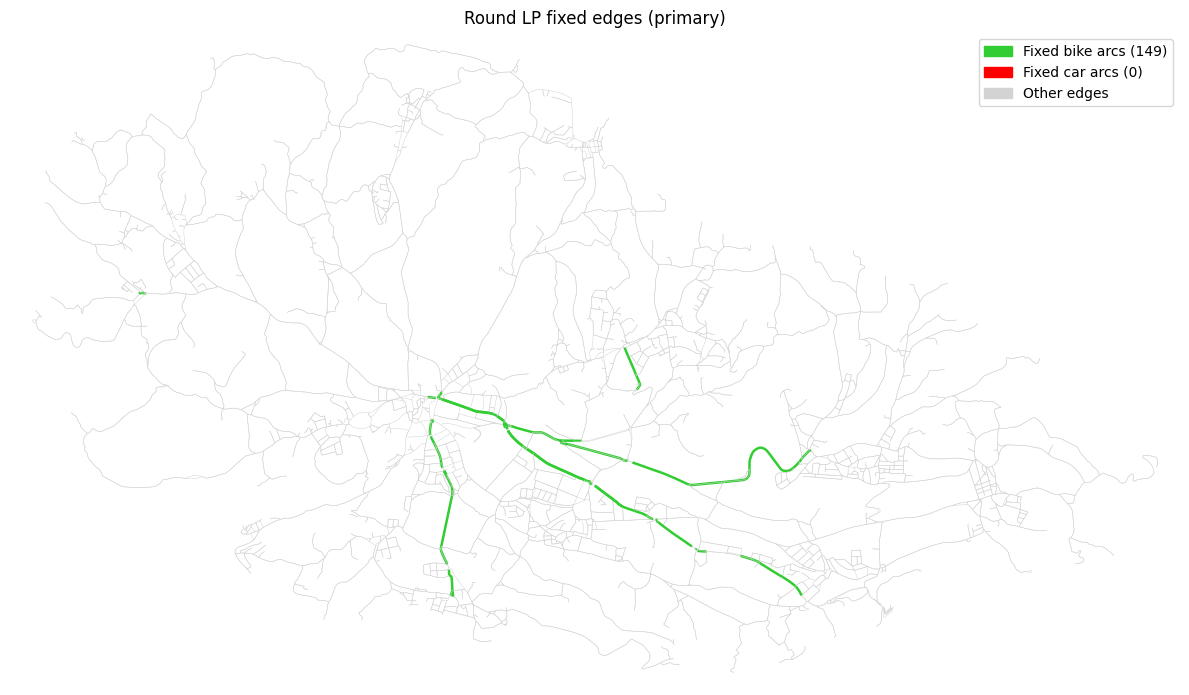

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Round LP fixed edges (primary)'}>)

In [ ]:
from Plotting.renderer import draw_graph
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_fixed_arcs(G, fixed_arcs_bike:set, fixed_arcs_car:set, title="Fixed arcs from rounding"):
    fixed_arcs_bike = set(fixed_arcs_bike)

    edge_colors = []
    edge_widths = []
    for u, v, k in G.edges(keys=True):
        arc = (u, v, k)
        if arc in fixed_arcs_bike:
            edge_colors.append("limegreen")
            edge_widths.append(1.8)
        elif arc in fixed_arcs_car:
            edge_colors.append("red")
            edge_widths.append(1)
        else:
            edge_colors.append("lightgray")
            edge_widths.append(0.35)

    fig, ax = draw_graph(
        G,
        edge_color=edge_colors,
        edge_linewidth=edge_widths,
        node_size=0,
        fig_size=(12, 12),
        bgcolor="white",
    )

    ax.legend(
        handles=[
            mpatches.Patch(color="limegreen", label=f"Fixed bike arcs ({len(fixed_arcs_bike)})"),
            mpatches.Patch(color="red", label=f"Fixed car arcs ({len(fixed_arcs_car)})"),
            mpatches.Patch(color="lightgray", label="Other edges"),
        ],
        loc="best",
    )
    ax.set_title(title)
    ax.axis("off")
    fig.tight_layout()
    plt.show()
    return fig, ax

# after your rounding call
plot_fixed_arcs(G_drive, fixed_main_1, fixed_main_0, title="Round LP fixed edges (primary)")


In [ ]:
fixed_main_0 = fixed_main_0 | (main_arcs - fixed_main_1)  # lock all main roads

# Pass 2: parallel localities
jobs = []    
for name, G_loc in subgraphs.items():
    eligible_loc = graph_util.make_reallocatable_subgraph(G_loc).edges(keys=True)
    eligible_loc = set(eligible_loc) - main_arcs
    od_loc = [od for od in od_all if od.origin in G_loc and od.destination in G_loc]
    jobs.append((name, G_loc, od_loc, eligible_loc, fixed_main_1, fixed_main_0, ...))

# run ProcessPoolExecutor over jobs -> locality results
# merge fixed sets -> global feasibility check

NameError: name 'od_all' is not defined